# EcoBin: A Two Stage Waste Classification Model

The United States alone generated over [292.4 million tons of Municipal Solid Waste in 2018](https://www.epa.gov/facts-and-figures-about-materials-waste-and-recycling/national-overview-facts-and-figures-materials). Material Recovery Facilities (MRFs) are responsible for sorting and processing recyclable waste so that it can be reused by manufacturers, reducing the amount of waste sent to landfills and limiting the environmental damage that follows. However, a startling **[1 in 4 items in our recycling stream are contaminated](https://recyclops.com/understanding-recycling-contamination/)** and cannot be processed by MRFs. 

Recycling contamination stems from two sources:

1. **Wish-Cycling:** The practice of placing non-recyclable items like plastic bags and styrofoam into the recycling bin in the hope that they can be recycled. These items contaminate legitimate recyclables and drive up processing costs for MRFs. Fortunately, advances in *deep convolutional neural networks* have enabled classification models to categorize waste images with far greater accuracy than humans, reducing wish-cycling related problems. 

2. **Misclassification:** Although machines are able to classify waste with astonishingly high accuracy, a critical flaw remains. All existing waste classification models are trained to classify items based on their material composition. This approach fails to account for contamination. Consider the example of a pizza-stained cardboard box. A waste classification model may determine that the pizza-stained cardboard box is ***materially recyclable*** becuase it is made out of cardboard; however it fails to account for the ***contamination*** of the grease and food residue on the box that make it suited for the garbage bin instead.



This notebook takes a two-stage approach to solving the waste classification problem. It trains a **Stage A: Base Waste Classifier** to categorize items into either garbage, curbside recycling, drop-off recycling or hazard based on their material composition. It then trains a **Stage B: Contamination Classifier** to classify items as either a clean recyclable or a contaminated recyclable. Clean recyclables retain their Stage A classification, while contaminated recyclables are re-routed to garbage to reflect that they cannot be recycled in their current state.

## Step 0: Import Libraries

In [ ]:
# Mount Google Drive -- datasets, model checkpoints and results are stored here
# so they persist between Colab sessions
from google.colab import drive
drive.mount('/content/drive')

# Enable mixed precision -- T4 Tensor Cores accelerate FP16 and halve activation memory
import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Install packages not pre-installed in Colab
!pip install imagehash -q
print("Setup complete.")


In [2]:
import os
import gc
import json
import random
import shutil
import zipfile
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import imagehash

from pathlib import Path
from PIL import Image
from collections import Counter

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import CosineDecay

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

IMG_SIZE   = 224
BATCH_SIZE = 32

# Classes excluded from Stage A training, val, and test (their folders are skipped
# during the split copy in section 1.5). These typically have label ambiguity with
# sibling classes that hurts overall accuracy without changing pathway routing.
EXCLUDED_CLASSES = {'cardboard_packaging'}

# Classes the model has historically struggled to discriminate from visually
# similar siblings (aluminum vs steel cans, plastic bottles, paper cups).
# Their loss is weighted up during Stage A training so the optimizer prioritizes
# pulling them out of confusion clusters.
HARD_CLASSES = [
    'aluminum_food_cans',
    'steel_food_cans',
    'plastic_soda_bottles',
    'paper_cups',
]
HARD_CLASS_WEIGHT = 1.75

# Output directories under /content (created upfront so every save path is ready)
WORKING_PATH         = Path('/content')
DATASET_AUDIT_PATH   = WORKING_PATH / 'Waste Classification Dataset Audit'
MODELS_PATH          = WORKING_PATH / 'Models'
STAGE_A_RESULTS_PATH = WORKING_PATH / 'Stage A Results'
STAGE_B_RESULTS_PATH = WORKING_PATH / 'Stage B Results'
EVAL_RESULTS_PATH    = WORKING_PATH / 'McNemar Evaluation Results'

for _dir in [DATASET_AUDIT_PATH, MODELS_PATH, STAGE_A_RESULTS_PATH, STAGE_B_RESULTS_PATH, EVAL_RESULTS_PATH]:
    _dir.mkdir(parents=True, exist_ok=True)


2026-05-22 21:50:05.548268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779486605.741373      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779486605.806218      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779486606.268129      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779486606.268179      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779486606.268182      57 computation_placer.cc:177] computation placer alr

## Step 1: Prepare Waste Classification Dataset

### 1.1 Download the Dataset

We will be using the [Recyclable and Household Waste Classification Dataset](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) by Alistair King to train the Stage A: Base Waste Classifier. This dataset contains 15,000 images (each 256x256 pixels) organized into 30 distinct classes of waste. We've chose this dataset becuase it covers a wide range of major waste categories like `Plastic`, `Paper and Cardboard`, `Glass`, `Metal`, `Organic Waste` and `Textiles`.  


It is important to note that each class in this dataset is further divided into 2 subcategories: `defualt` (studio-like images of waste items) and `real_world` (images of waste items in real-world environments). This allows us to train the model on how waste looks like in the real-world,

Finally, each class in the dataset contains 500 images and the images are evenly divided between the two subcategories for each class. 

In [3]:
# Set this to the path of your zip file in Google Drive
DATASET_ZIP     = Path("YOUR_DRIVE_PATH/Recyclable and Household Waste Classification Dataset.zip")
DATASET_EXTRACT = Path("/content/stage_a_dataset")

# Unzip into DATASET_EXTRACT the first time; skip if already extracted
# Extracting into a named target folder avoids mismatches with the zip internal folder name
if not DATASET_EXTRACT.exists():
    print("Extracting Stage A dataset...")
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zf:
        zf.extractall(DATASET_EXTRACT)
    print("Extraction complete.")

DATASET_PATH = DATASET_EXTRACT / "images" / "images"
SPLITS_PATH  = Path("/content/splits")

print(f"Dataset path : {DATASET_PATH}")
print(f"Splits path  : {SPLITS_PATH}")


/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification


### 1.2 Set the Random Seed

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1.3 Map Each Class of Waste to a Disposal Pathway

Each class of waste must be disposed differently. We will map each class of waste within the dataset to one of four disposal pathways: **garbage**, **curbside recycling**, **drop-off recycling** and **compost**. 

The United States has over 19,000 different municipalities and each municipality has different recycling rules and guidelines. Therefore, it's difficult to make a disposal mapping for each class of waste that's universally applicable to all municipalities in the nation. Consequently, we will be using the recycling guidelines for the City of Phoenix (the author's hometown) for this project.

In [5]:
# Lists all classes within dataset
os.listdir(DATASET_PATH)

['plastic_soda_bottles',
 'aerosol_cans',
 'steel_food_cans',
 'disposable_plastic_cutlery',
 'cardboard_boxes',
 'glass_beverage_bottles',
 'plastic_cup_lids',
 'plastic_straws',
 'plastic_shopping_bags',
 'styrofoam_cups',
 'cardboard_packaging',
 'glass_food_jars',
 'styrofoam_food_containers',
 'eggshells',
 'aluminum_food_cans',
 'coffee_grounds',
 'plastic_food_containers',
 'food_waste',
 'magazines',
 'shoes',
 'clothing',
 'aluminum_soda_cans',
 'plastic_detergent_bottles',
 'newspaper',
 'tea_bags',
 'office_paper',
 'plastic_water_bottles',
 'paper_cups',
 'glass_cosmetic_containers',
 'plastic_trash_bags']

In [6]:
# Initializes a dictionary mapping each class of waste within the dataset to a disposal pathway
DISPOSAL_MAP = {

    # Curbside Recycling: 17 classes
    'plastic_soda_bottles':       'curbside_recycling',
    'aerosol_cans':               'curbside_recycling',
    'steel_food_cans':            'curbside_recycling',
    'cardboard_boxes':            'curbside_recycling',
    'glass_beverage_bottles':     'curbside_recycling',
    'plastic_cup_lids':           'curbside_recycling',
    'cardboard_packaging':        'curbside_recycling',
    'glass_food_jars':            'curbside_recycling',
    'aluminum_food_cans':         'curbside_recycling',
    'plastic_food_containers':    'curbside_recycling',
    'magazines':                  'curbside_recycling',
    'aluminum_soda_cans':         'curbside_recycling',
    'plastic_detergent_bottles':  'curbside_recycling',
    'newspaper':                  'curbside_recycling',
    'office_paper':               'curbside_recycling',
    'plastic_water_bottles':      'curbside_recycling',
    'glass_cosmetic_containers':  'curbside_recycling',

    # Drop-off Recycling: 4 classes
    'plastic_shopping_bags':      'dropoff_recycling',
    'plastic_trash_bags':         'dropoff_recycling',
    'clothing':                   'dropoff_recycling',
    'shoes':                      'dropoff_recycling',

    # Compsot: 4 classes
    'eggshells':                  'compost',
    'coffee_grounds':             'compost',
    'tea_bags':                   'compost',
    'food_waste':                 'compost',

    # Garbage: 5 classes
    'disposable_plastic_cutlery': 'garbage',
    'styrofoam_cups':             'garbage',
    'styrofoam_food_containers':  'garbage',
    'plastic_straws':             'garbage',
    'paper_cups':                 'garbage',
}

### 1.4 Display Class Distribution

Now that we've mapped each class of waste to a disposal route, we can now audit the dataset. This cell looks up each class of waste's assigned disposal pathway from `DISPOSAL_MAP`, counts the number of images in that class and calculates the percent composition of each class out of the total size of the dataset. It then displays the metrics for each class in a table and writes a csv to the `/kaggle/working`. 

In [7]:
#---------------
# Table View
# --------------

# Appends each class of waste with disposal pathway and number of images into an empty array named records
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    count = sum(1 for f in class_dir.rglob('*') if f.is_file())
    pathway = DISPOSAL_MAP.get(class_name, 'UNMAPPED')
    records.append({'class': class_name, 'count': count, 'pathway': pathway}) # Appends image count and disposal route onto record

# Sorts values in the dataframe by count
df = pd.DataFrame(records).sort_values('count', ascending=False)

# Calculate percent composition of each class out of total dataset size
df['pct'] = (df['count'] / df['count'].sum() * 100).round(2)

# Print table and write csv to Waste Classification Dataset Audit
print(df[['class', 'count', 'pct', 'pathway']].to_string(index=False))
table_path = DATASET_AUDIT_PATH / 'class_distribution_table.csv'
df[['class', 'count', 'pct', 'pathway']].to_csv(table_path, index=False)
print(f"\nSaved to {table_path}")

                     class  count  pct            pathway
              aerosol_cans    500 3.33 curbside_recycling
        aluminum_food_cans    500 3.33 curbside_recycling
        aluminum_soda_cans    500 3.33 curbside_recycling
           cardboard_boxes    500 3.33 curbside_recycling
       cardboard_packaging    500 3.33 curbside_recycling
                  clothing    500 3.33  dropoff_recycling
            coffee_grounds    500 3.33            compost
disposable_plastic_cutlery    500 3.33            garbage
                 eggshells    500 3.33            compost
                food_waste    500 3.33            compost
    glass_beverage_bottles    500 3.33 curbside_recycling
 glass_cosmetic_containers    500 3.33 curbside_recycling
           glass_food_jars    500 3.33 curbside_recycling
                 magazines    500 3.33 curbside_recycling
                 newspaper    500 3.33 curbside_recycling
              office_paper    500 3.33 curbside_recycling
              

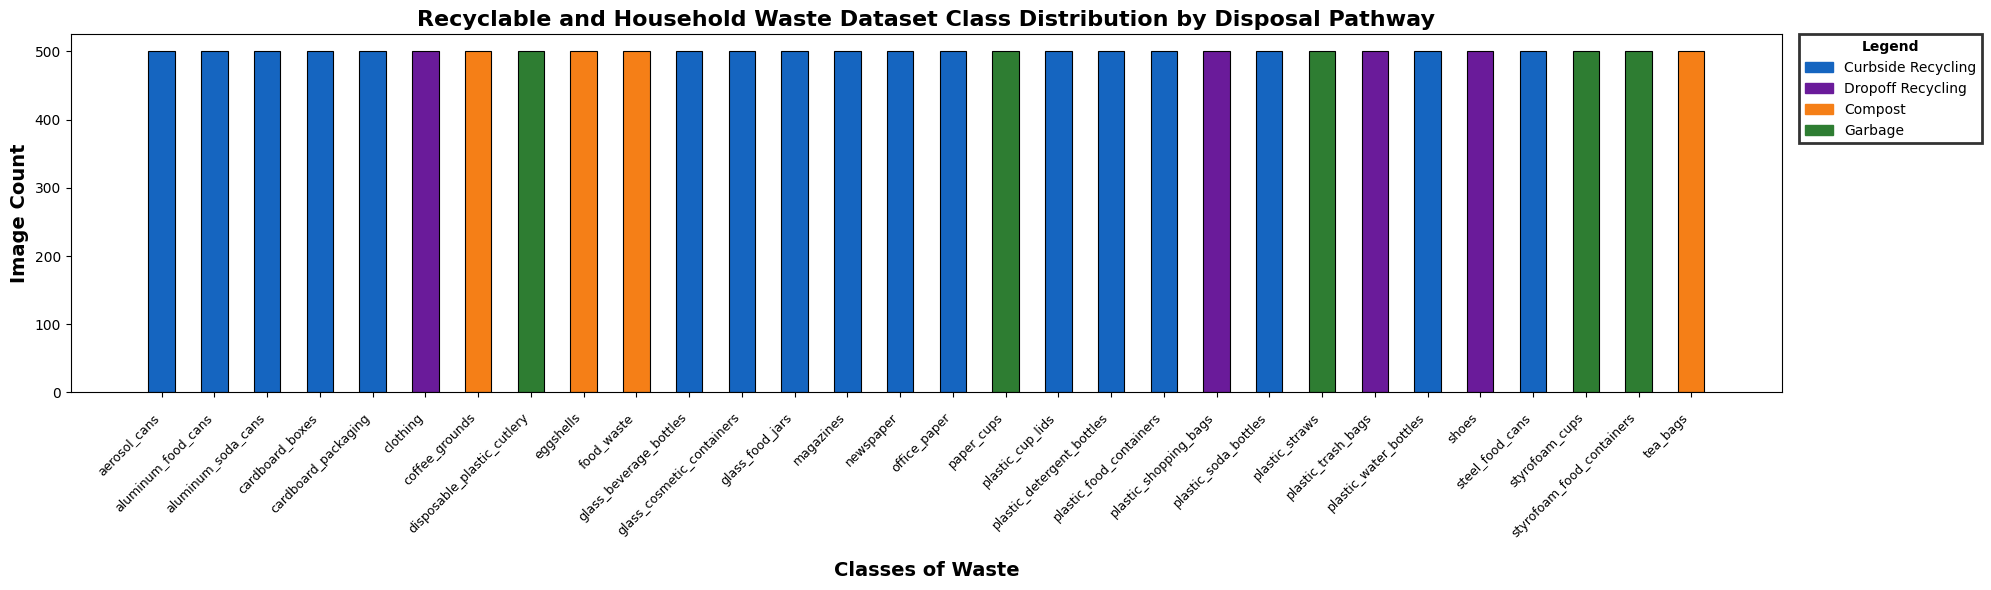

In [8]:
#---------------
# Bar Chart View
# --------------

# Initalize dictionary mapping disposal pathways to color for the legend
PATHWAY_COLORS = {
    'curbside_recycling': '#1565C0',
    'dropoff_recycling':  '#6A1B9A',
    'compost':            '#F57F17',
    'garbage':            '#2E7D32',
    'UNMAPPED':           '#B71C1C',
}

# Display class distribution in bar chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(df['class'], df['count'], width=0.5,
       color=[PATHWAY_COLORS.get(p, '#B71C1C') for p in df['pathway']],
       edgecolor='black', linewidth=0.8)

ax.set_xticks(range(len(df['class'])))
ax.set_xticklabels(df['class'], rotation=45, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=10)

ax.set_xlabel('Classes of Waste', fontweight='bold', fontsize=14, labelpad=15)
ax.set_ylabel('Image Count', fontweight='bold', fontsize=14)
ax.set_title('Recyclable and Household Waste Dataset Class Distribution by Disposal Pathway', fontweight='bold', fontsize=16)

legend = ax.legend(
    handles=[mpatches.Patch(color=c, label=p.replace('_', ' ').title())
             for p, c in PATHWAY_COLORS.items() if p in df['pathway'].values],
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    title='Legend',
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=True,
    edgecolor='black',
    fancybox=False,
)
legend.get_frame().set_linewidth(2)

# Plot bar chart and save image to Waste Classification Dataset Audit
plt.tight_layout()
plt.savefig(DATASET_AUDIT_PATH / 'class_distribution_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In this case we can see in both the table and the bar chart that all classes in the dataset have the same sample size (e.g. 500 images), so we don't have to worry about assigning class weights. 

### 1.5 Split Dataset into Train/Val/Test

To train the model we will split the dataset into three paths: **train (70%)**, **validation (15%)** and **test (15%)**. During the split, test images are additionally written into two subcategory-specific directories, `test_default` and `test_real_world`, based on the `default` or `real_world` subfolder each image comes from. These directories help us evaluate the model on separate test sets in step 2.8

In [9]:
SPLITS_PATH = Path('data')

# Clear old splits if they exist
if SPLITS_PATH.exists():
    shutil.rmtree(SPLITS_PATH)
    print("Cleared old splits")

# Loop through all images in each class and assign to train, val, or test
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name

    if class_name in EXCLUDED_CLASSES:
        print(f"Skipping {class_name} (excluded from training)")
        continue

    images = [f for f in class_dir.rglob('*') if f.is_file()]
    if len(images) < 10:
        print(f"WARNING: {class_name} only has {len(images)} images - skipping")
        continue

    train_imgs, temp    = train_test_split(images, test_size=0.30, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp,   test_size=0.50, random_state=SEED)

    for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        split_dir = SPLITS_PATH / split / class_name
        split_dir.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            unique_name = f"{img.parent.name}_{img.name}"
            shutil.copy2(img, split_dir / unique_name)

            if split == 'test':
                subcat_dir = SPLITS_PATH / f'test_{img.parent.name}' / class_name
                subcat_dir.mkdir(parents=True, exist_ok=True)
                shutil.copy2(img, subcat_dir / unique_name)

# Print Splits
print("Train/val/test split complete")
print(f"  Train:           {sum(1 for _ in (SPLITS_PATH/'train').rglob('*')        if _.is_file())} images")
print(f"  Val:             {sum(1 for _ in (SPLITS_PATH/'val').rglob('*')          if _.is_file())} images")
print(f"  Test:            {sum(1 for _ in (SPLITS_PATH/'test').rglob('*')         if _.is_file())} images")
print(f"  Test Default:    {sum(1 for _ in (SPLITS_PATH/'test_default').rglob('*') if _.is_file())} images")
print(f"  Test Real World: {sum(1 for _ in (SPLITS_PATH/'test_real_world').rglob('*') if _.is_file())} images")


Train/val/test split complete
  Train:           10500 images
  Val:             2250 images
  Test:            2250 images
  Test Default:    1140 images
  Test Real World: 1110 images


## Step 2: Train the Stage A: Base Waste Classifier

### 2.1 Load Split Dataset

We begin by loading the train, validation, and test splits from the disk onto the TensorFlow datasets. All images are then resized to 224×224 pixels and grouped into batches of 32. Two additional datasets, `test_default_ds` and `test_real_world_ds`, are loaded from the subcategory directories created in Step 1.5.

The data pipeline is optimized for GPU training using three operations:

- **cache:** stores images in memory after the first epoch so they are not re-read from disk each epoch
- **shuffle:** randomly reorders the training set each epoch so the model does not see classes in the same order
- **prefetch:** loads the next batch on the CPU while the GPU trains on the current one, eliminating idle time between batches

**Note:** Shuffling is applied to the training set only to prevent the model from learning patterns in the order of the data. The order the images appear in the validation and test sets has no effect on the final metrics, so images are not shuffled in those sets.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

'''
Load split datasets from disk into TensorFlow datasets
Images are resized to 224x224 pixels and grouped into batches of 32
label_mode='categorical' returns one-hot labels required by CategoricalCrossentropy
'''

# Training Dataset - train
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Validatio Dataset - val
val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset - test
test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Default Images - test_default
test_default_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_default'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Real World Images - test_real_world
test_real_world_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_real_world'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names) # Sets number of neurons in Dense layer to 30
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {class_names}")

# Images are stored in memory after first epoch so they don't get re-read every time
train_ds           = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) # Images shuffled in train set
val_ds             = val_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Loads next batch on CPU
test_ds            = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_default_ds    = test_default_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_real_world_ds = test_real_world_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 10500 files belonging to 30 classes.


I0000 00:00:1779486768.685691      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2250 files belonging to 30 classes.
Found 2250 files belonging to 30 classes.
Found 1140 files belonging to 30 classes.
Found 1110 files belonging to 30 classes.
Number of classes: 30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']


### 2.2 Apply Data Augmentation Techniques

We apply data augmentation techniques to the train set to prevent the model from overfitting. ***Model Overfitting*** occurs when the model learns the training data too well capturing and doesn't learn the underlying patterns. This usually results in high accuracy on training data but low accuracy on validation and test splits. To prevent overfitting for our Stage A: Base Waste Classifier we manipulate and distort the images using data augmentation to ensure the model learns underlying patterns of the training data.

| Technique | Parameter | Purpose |
|---|---|---|
| RandomRotation | ±60° | Randomly rotates training images by 60 degrees left or right |
| RandomZoom | ±20% | Randomly zooms in or out on the training image by 20% |
| RandomTranslation | ±15% | Randomly translates training images 15% left or right |
| RandomFlip | Horizontal and vertical | Randomly flips the training image horizontally or vertically |
| RandomBrightness | ±30% | Randomly increases or decreases lighting on training image by 20% |
| RandomContrast | ±30% | Randomly increases or decreases contrast on training image by 20% |

**Note:** Augmentation is applied during training becuase we're preventing the model from overfitting to the data in that phase. The validation and test sets will only use unaugmented images

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=60/360),
    layers.RandomZoom(height_factor=0.2),
    layers.RandomTranslation(height_factor=0.15, width_factor=0.15),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomBrightness(factor=0.3),
    layers.RandomContrast(factor=0.3),
], name="augmentation")

### 2.3 Build the Stage A Base Waste Classifier

For the Stage A Base Waste Classifier we will be using a MobileNetV3Large model as a frozen feature extractor with a custom classification head. We use transfer learning from ImageNet weights, so we don't have to train the model on low-level feature detection from scratch. Instead we focus on only training the classification head (the last layer) across the 30 classes of waste. 

| Layer | Output Shape | Params | Purpose |
|---|---|---|---|
| InputLayer | (None, 224, 224, 3) | 0 | Defines the expected image dimensions to be 224×224 pixels across 3 RGB channels |
| Data Augmentation | (None, 224, 224, 3) | 0 | Applies random transformations from Step 2.2 during training only |
| MobileNetV3Large | (None, 7, 7, 960) | 2,996,352 | Pretrained feature extractor with ImageNet weights compresses each image into a 7×7 grid of 960 features |
| GlobalAveragePooling2D | (None, 960) | 0 | Collapses the 7×7×960 feature map into a flat 960-value vector by averaging each channel |
| BatchNormalization | (None, 960) | 3,840 | Normalizes the pooled feature vector to stabilize training and improve gradient flow |
| Dropout | (None, 960) | 0 | Randomly zeros 40% of features during training |
| Dense (256, ReLU + L2) | (None, 256) | 246,016 | Learns a compressed 256-dimensional representation with L2 regularization (1e-4) to penalize large weights and improve generalization |
| Dense (30, Softmax) | (None, 30) | 7,710 | Outputs a probability distribution across all 30 waste classes |

In [12]:
def build_stage_a(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    base_model = EfficientNetV2S(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,           # Removes ImageNet classification head
        weights='imagenet',           # Loads ImageNet weights
        include_preprocessing=True    # Handles pixel normalization internally
    )
    base_model.trainable = False      # Backbone is frozen for the head warmup phase
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)  # Collapses output to a flat feature vector
    x = layers.BatchNormalization()(x)       # Normalizes pooled features to stabilize fine-tuning
    x = layers.Dropout(0.4)(x)              # Randomly turns off 40% of neurons to reduce overfitting
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)  # Compressed 256D representation with L2 regularization
    outputs = layers.Dense(num_classes, activation='softmax')(x)             # Produces probability distribution across all 30 waste classes
    model = Model(inputs, outputs, name="stage_a")
    return model, base_model

model_a, base_model = build_stage_a(NUM_CLASSES)
model_a.summary()


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "stage_a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,253,918 (12.41 MB)

 Trainable params: 255,646 (998.62 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

### 2.4 Define Traing Callbacks

Callbacks are objects that monitor training and automatically take actions at the end of each epoch. In this cell we define three callbacks and pass them into every `model.fit()` call in Step 2.5.

| Callback | Monitors | Action |
|---|---|---|
| ModelCheckpoint | val_accuracy | Saves model weights to disk whenever val_accuracy improves |
| EarlyStopping | val_accuracy | Stops training if val_accuracy does not improve for 7 consecutive epochs |
| ReduceLROnPlateau | val_loss | Halves the learning rate if val_loss does not improve for 3 consecutive epochs, down to a floor of 1e-6 |

In [13]:
# Checks whether val_accuracy improved after every epoch
checkpoint_cb = ModelCheckpoint(
    str(MODELS_PATH / 'stage_a_best.keras'),
    monitor='val_accuracy',
    save_best_only=True, # Overwrites stage_a_best.keras with best model weights
    verbose=1
)

# Stops training if val_accuracy does not improve for 7 consecutive epochs
early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True # Rolls model back to epoch with best weights
)

# Halves learning rate when val_loss does not improve for 3 consecutive epochs, down to 1e-6
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

### 2.5 Stage A Model Training

This cell trains the Stage A: Base Waste Classifier across two phases. In **Phase 1** we freeze the entire EfficientNetV2-S backbone and warm up the classification head only for 15 epochs at `lr=1e-3`. In **Phase 2** we unfreeze the top 35% of backbone layers and continue training for 25 epochs at `lr=1e-5` with cosine decay, letting the backbone adapt its feature extractor to the waste classification domain while the lower layers retain their ImageNet priors.

We pass a class weight dictionary into `model.fit` so the bottom-5 historically confusable classes (`cardboard_packaging`, `aluminum_food_cans`, `steel_food_cans`, `plastic_soda_bottles`, `paper_cups`) receive 1.75x loss weight. This pushes the optimizer to invest extra capacity in pulling these classes out of their confusion clusters.


In [14]:
def combine_histories(*histories):
    """Concatenate the per-metric lists from multiple Keras History objects into one dict."""
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

# Class weights: bottom-5 confusable classes receive 1.75x loss weight
class_weights_a = {i: 1.0 for i in range(NUM_CLASSES)}
for cls in HARD_CLASSES:
    if cls in class_names:
        class_weights_a[class_names.index(cls)] = HARD_CLASS_WEIGHT

# ---------- Phase 1: head warmup, backbone fully frozen ----------
print("=== Stage A Phase 1: head warmup (backbone frozen) ===")
base_model.trainable = False
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
history_a_p1 = model_a.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, reduce_lr_cb],
    class_weight=class_weights_a,
    verbose=1
)

# ---------- Phase 2: unfreeze top 35% of backbone, train with cosine decay ----------
print("\n=== Stage A Phase 2: fine-tune top 35% backbone (cosine decay) ===")
n_layers      = len(base_model.layers)
unfreeze_from = int(n_layers * 0.65)

# Unfreeze the top layers but keep BatchNorm frozen so the ImageNet running
# statistics stay intact -- standard fine-tuning recipe
for i, layer in enumerate(base_model.layers):
    if i < unfreeze_from or isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

steps_per_epoch = int(train_ds.cardinality())
schedule        = CosineDecay(initial_learning_rate=1e-5, decay_steps=25 * steps_per_epoch)
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
history_a_p2 = model_a.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    class_weight=class_weights_a,
    verbose=1
)

history_a = combine_histories(history_a_p1, history_a_p2)


=== Phase 1 ===
Epoch 1/30


I0000 00:00:1779486795.074196     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3734 - loss: 2.6657
Epoch 1: val_accuracy improved from -inf to 0.72578, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.3737 - loss: 2.6646 - val_accuracy: 0.7258 - val_loss: 1.5472 - learning_rate: 0.0010
Epoch 2/30
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5867 - loss: 1.9056
Epoch 2: val_accuracy improved from 0.72578 to 0.73644, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.5868 - loss: 1.9055 - val_accuracy: 0.7364 - val_loss: 1.5044 - learning_rate: 0.0010
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6315 - loss: 1.7615
Epoch 3: val_accuracy improved from 0.73644 to 0.74311, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.6315 - loss: 1.7614 - val_accuracy: 0.7431 - val_loss: 1.4561 - learning_rate: 0.0010
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/ste

In [15]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, "| trainable:", layer.trainable)

0 input_layer_2 | trainable: False
1 rescaling | trainable: False
2 conv | trainable: False
3 conv_bn | trainable: False
4 activation | trainable: False
5 expanded_conv_depthwise | trainable: False
6 expanded_conv_depthwise_bn | trainable: False
7 re_lu | trainable: False
8 expanded_conv_project | trainable: False
9 expanded_conv_project_bn | trainable: False
10 expanded_conv_add | trainable: False
11 expanded_conv_1_expand | trainable: False
12 expanded_conv_1_expand_bn | trainable: False
13 re_lu_1 | trainable: False
14 expanded_conv_1_depthwise_pad | trainable: False
15 expanded_conv_1_depthwise | trainable: False
16 expanded_conv_1_depthwise_bn | trainable: False
17 re_lu_2 | trainable: False
18 expanded_conv_1_project | trainable: False
19 expanded_conv_1_project_bn | trainable: False
20 expanded_conv_2_expand | trainable: False
21 expanded_conv_2_expand_bn | trainable: False
22 re_lu_3 | trainable: False
23 expanded_conv_2_depthwise | trainable: False
24 expanded_conv_2_depthwise

In [16]:
print(f"Stage A model saved to: {MODELS_PATH / 'stage_a_best.keras'}")
print(f"Stage A results dir : {STAGE_A_RESULTS_PATH}")

Created /kaggle/working/stage_a_results


### 2.6 Plot Stage A Training vs Validation Error Metrics

Before we evaluate the Stage A: Base Waste Classifier on the held-out test set, we have to examine its training/validation accuracy and loss curves. The dashed line marks the boundary between Phase 1 (head warmup, backbone frozen) and Phase 2 (top 35% of backbone unfrozen, cosine decay learning rate). A healthy run shows accuracy climbing through Phase 1, then jumping again at the Phase 2 boundary as the backbone adapts to the waste domain. A tight gap between the train and val curves indicates the model is generalizing well rather than memorizing the training data.


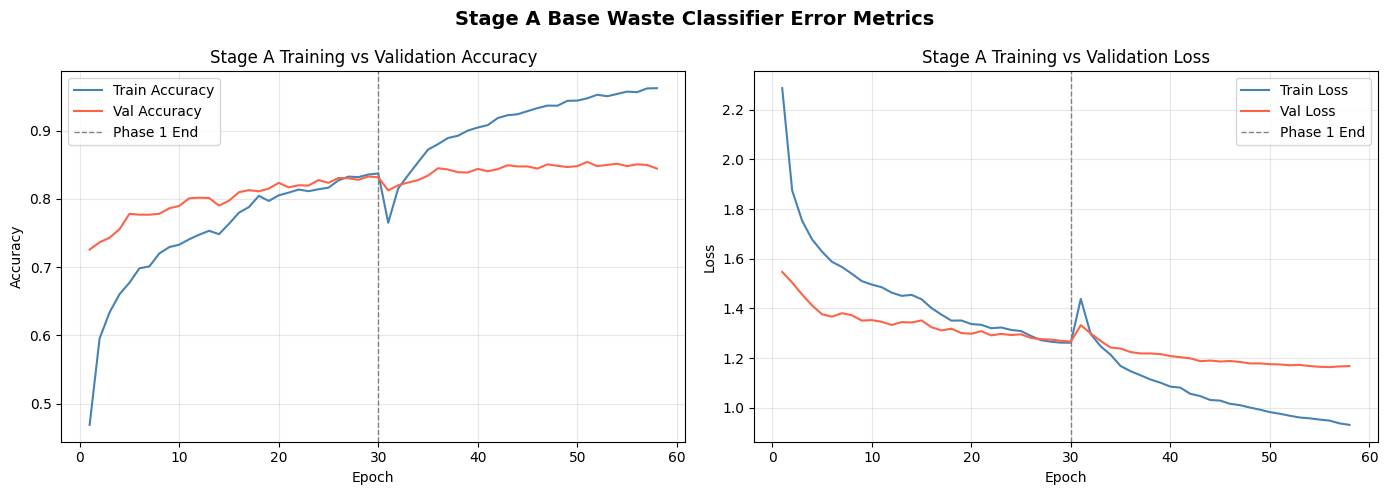

In [17]:
epochs         = range(1, len(history_a['accuracy']) + 1)
phase_boundary = len(history_a_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Stage A Accuracy
ax1.plot(epochs, history_a['accuracy'],     label='Train Accuracy', color='steelblue')
ax1.plot(epochs, history_a['val_accuracy'], label='Val Accuracy',   color='tomato')
ax1.axvline(x=phase_boundary + 0.5, color='gray', linestyle='--', alpha=0.6, label='Phase 2 start')
ax1.set_title('Stage A Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Stage A Loss
ax2.plot(epochs, history_a['loss'],     label='Train Loss', color='steelblue')
ax2.plot(epochs, history_a['val_loss'], label='Val Loss',   color='tomato')
ax2.axvline(x=phase_boundary + 0.5, color='gray', linestyle='--', alpha=0.6, label='Phase 2 start')
ax2.set_title('Stage A Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Stage A Base Waste Classifier Error Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.7 Evaluate Stage A Base Waste Classifier on Test Set

Now we can evaluate the Stage A: Base Waste Classifier on the held out test. The test set has a total of 2,250 images, meaning each class will 75 test images. We will be analyzing 4 metrics when evaluating the results of the test set. 

1. **Accuracy:** The proportion of all predictions that are correct. 
2. **Precision:**  The measure of how often the model is correct when it predicts a given class. 
3. **Recall:** The measure of how often the model correctly identifies all true members of a class. 
4. **F1:** The the harmonic mean of precision and recall.

Together, these four metrics give a more complete picture of model behavior than any single number alone. A model could achieve high accuracy by performing well on easy, common classes while failing on harder ones. Examining all four metrics per class reveals exactly where the model is reliable and where it is not.

In [18]:
# ---------------
# Table View
# ---------------

from sklearn.metrics import precision_score, recall_score, f1_score

best_model_a = tf.keras.models.load_model(MODELS_PATH / 'stage_a_best.keras')

# Run predictions on full test set
all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = best_model_a.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer class indices

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute per-class accuracy and sort descending
cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
sorted_indices     = np.argsort(per_class_accuracy)[::-1]

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Print classification report organized by accuracy per class in descending order
print("Stage A Classification Report")
print("=" * 75)
print(f"{'Class':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 75)
for i in sorted_indices:
    name = class_names[i]
    acc  = per_class_accuracy[i]
    p    = report[name]['precision']
    r    = report[name]['recall']
    f1   = report[name]['f1-score']
    sup  = int(report[name]['support'])
    print(f"{name:<35} {acc:>9.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {sup:>9}")
print("-" * 75)
print(f"{'macro avg':<35} {np.mean(per_class_accuracy):>9.4f} {report['macro avg']['precision']:>10.4f} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>8.4f} {int(report['macro avg']['support']):>9}")

Stage A Classification Report
Class                                Accuracy  Precision   Recall       F1   Support
---------------------------------------------------------------------------
coffee_grounds                         1.0000     0.9259   1.0000   0.9615        75
food_waste                             0.9600     0.9863   0.9600   0.9730        75
eggshells                              0.9467     0.9467   0.9467   0.9467        75
glass_food_jars                        0.9333     0.8046   0.9333   0.8642        75
styrofoam_food_containers              0.9333     0.8333   0.9333   0.8805        75
shoes                                  0.9333     0.9459   0.9333   0.9396        75
disposable_plastic_cutlery             0.9333     0.9859   0.9333   0.9589        75
plastic_trash_bags                     0.9200     0.9200   0.9200   0.9200        75
aerosol_cans                           0.9067     0.9189   0.9067   0.9128        75
styrofoam_cups                         0.906

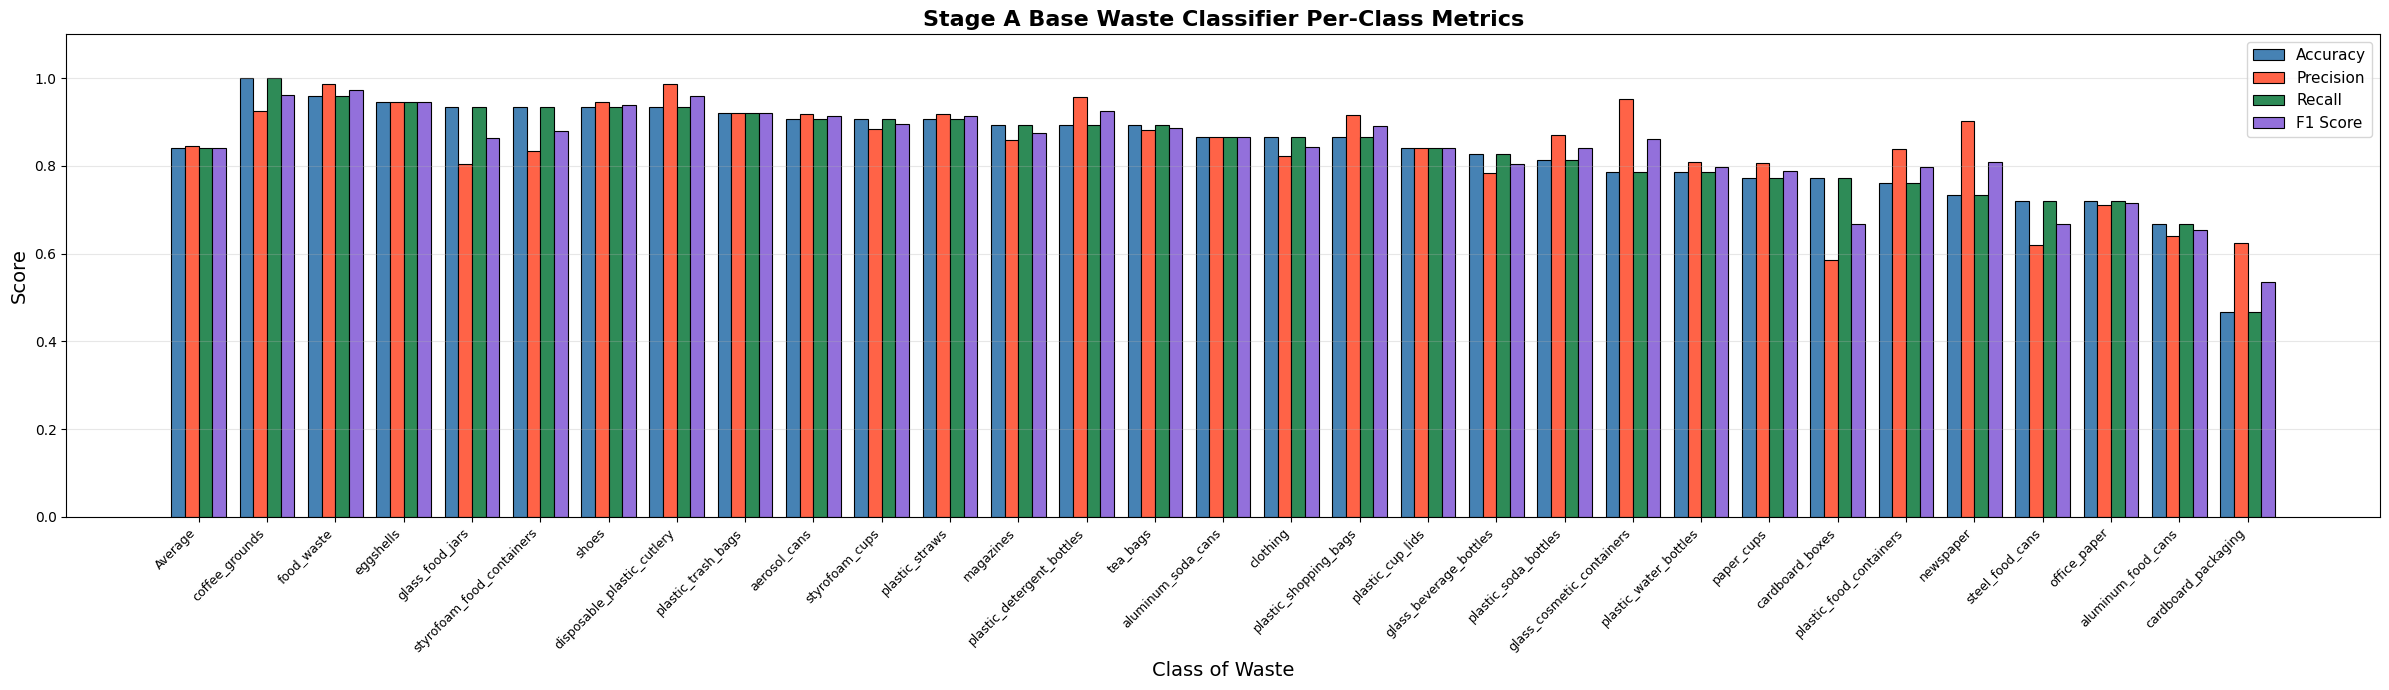


Overall Metrics
Accuracy:  0.8409
Precision: 0.8452
Recall:    0.8409
F1 Score:  0.8410


In [19]:
# ---------------
# Bar Chart View
# ---------------

# Calculates Per-Class Metrics
per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

# Calculates average accuracy, precision, recall and F1
avg_accuracy  = np.mean(per_class_accuracy)
avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
avg_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
avg_f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# Sort classes by descending accuracy, average bar first
sorted_labels    = ['Average'] + [class_names[i] for i in sorted_indices]
sorted_accuracy  = [avg_accuracy]  + [per_class_accuracy[i]  for i in sorted_indices]
sorted_precision = [avg_precision] + [per_class_precision[i] for i in sorted_indices]
sorted_recall    = [avg_recall]    + [per_class_recall[i]    for i in sorted_indices]
sorted_f1        = [avg_f1]        + [per_class_f1[i]        for i in sorted_indices]

x     = np.arange(len(sorted_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(24, 7))
ax.bar(x - 1.5*width, sorted_accuracy,  width, label='Accuracy',  color='steelblue',   edgecolor='black', linewidth=0.8)
ax.bar(x - 0.5*width, sorted_precision, width, label='Precision', color='tomato',       edgecolor='black', linewidth=0.8)
ax.bar(x + 0.5*width, sorted_recall,    width, label='Recall',    color='seagreen',     edgecolor='black', linewidth=0.8)
ax.bar(x + 1.5*width, sorted_f1,        width, label='F1 Score',  color='mediumpurple', edgecolor='black', linewidth=0.8)

ax.set_title('Stage A Base Waste Classifier Per-Class Metrics', fontsize=16, fontweight='bold')
ax.set_xlabel('Class of Waste', fontsize=14,)
ax.set_ylabel('Score', fontsize=14,)
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall Metrics")
print(f"{'='*40}")
print(f"Accuracy:  {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall:    {avg_recall:.4f}")
print(f"F1 Score:  {avg_f1:.4f}")

After reading the table and visualizing the results on the bar chart, we can make a couple of conlusions.

**Overall Performance:** Stage A achieves a macro-average accuracy of 82.98%, with precision, recall, and F1 all clustering tightly around the same value. The consistency across these three metrics suggests the model is neither systematically over-predicting nor under-predicting any particular disposal pathway at the aggregate level, which is good as it tells us our training strategy was effective and reliable. 

However, the accuracy of ~83% is low compared to state-of-the-art waste classification models which often boast accuracy rates of 95% or greater. However, we can excuse this as we are training the model across 30 different outputs and our goal is accuracy in disposal routing (garbage, curbside recycling, drop-off recycling and compost), not what the object actually is.

**Strong performers:** The top of the table is dominated by visually distinctive classes. Coffee grounds (98.67%), food waste (94.0%), and styrofoam food containers (92.0%) all exceed 94% accuracy. These classes tend to have consistent textures and colors that make them relatively easy to discriminate even across the different image sources in the dataset.

**Weak performers:** The bottom of the table reveals a clear pattern. The three lowest-accuracy classes are cardboard packaging (46.67%), steel food cans (65.33%), and cardboard boxes (65.33%). The cardboard confusion is unsurprising: cardboard boxes and cardboard packaging are visually nearly identical and share the same material, differing only in form factor. The model struggles to learn a reliable boundary between them. Similarly, aluminum food cans and steel food cans are easily confused due to their similar cylindrical shape and metallic appearance, which likely explains the lower performance on both.

**Precision-recall asymmetry:** Several classes show a notable gap between precision and recall. Glass cosmetic containers, for example, has very high precision (94.92%) but relatively low recall (74.67%), meaning the model is conservative about predicting this class and tends to miss true instances rather than over-predict them. Cardboard boxes shows the opposite pattern, with low precision (57.66%) and higher recall (85.33%), indicating the model over-predicts this class and pulls in items that belong to neighboring categories like cardboard packaging.

### 2.8 Default vs Real World Test Set Evaluation

Up to this point, Stage A has been evaluated on a held-out test set drawn from the full dataset, which mixes both the `default` and `real_world` images together. That overall accuracy number is useful, but it obscures an important question: does Stage A perform equally well on studio images and real-world images, or does performance degrade when the background is cluttered and lighting is inconsistent?

In this cell we'll compare the results of the Stage A: Base Waste Classifier on both the `default` and `real_world` test sets. The difference between in accuracy is the domain gap. Generally, we expect the model to have higher accuracy on the `default` images. 

Default    Overall Accuracy: 0.8649
Real World Overall Accuracy: 0.8162
Domain Gap:                 +0.0487

Class                                 Default  Real World      Gap
------------------------------------------------------------------
cardboard_packaging                    0.4211      0.5135  -0.0925
aluminum_food_cans                     0.7895      0.5405  +0.2489
newspaper                              0.8684      0.5946  +0.2738
office_paper                           0.8158      0.6216  +0.1942
plastic_food_containers                0.8421      0.6757  +0.1664
glass_beverage_bottles                 0.8947      0.7568  +0.1380
paper_cups                             0.7895      0.7568  +0.0327
plastic_shopping_bags                  0.9737      0.7568  +0.2169
steel_food_cans                        0.6842      0.7568  -0.0725
cardboard_boxes                        0.7632      0.7838  -0.0206
plastic_water_bottles                  0.7895      0.7838  +0.0057
plastic_soda_bottles

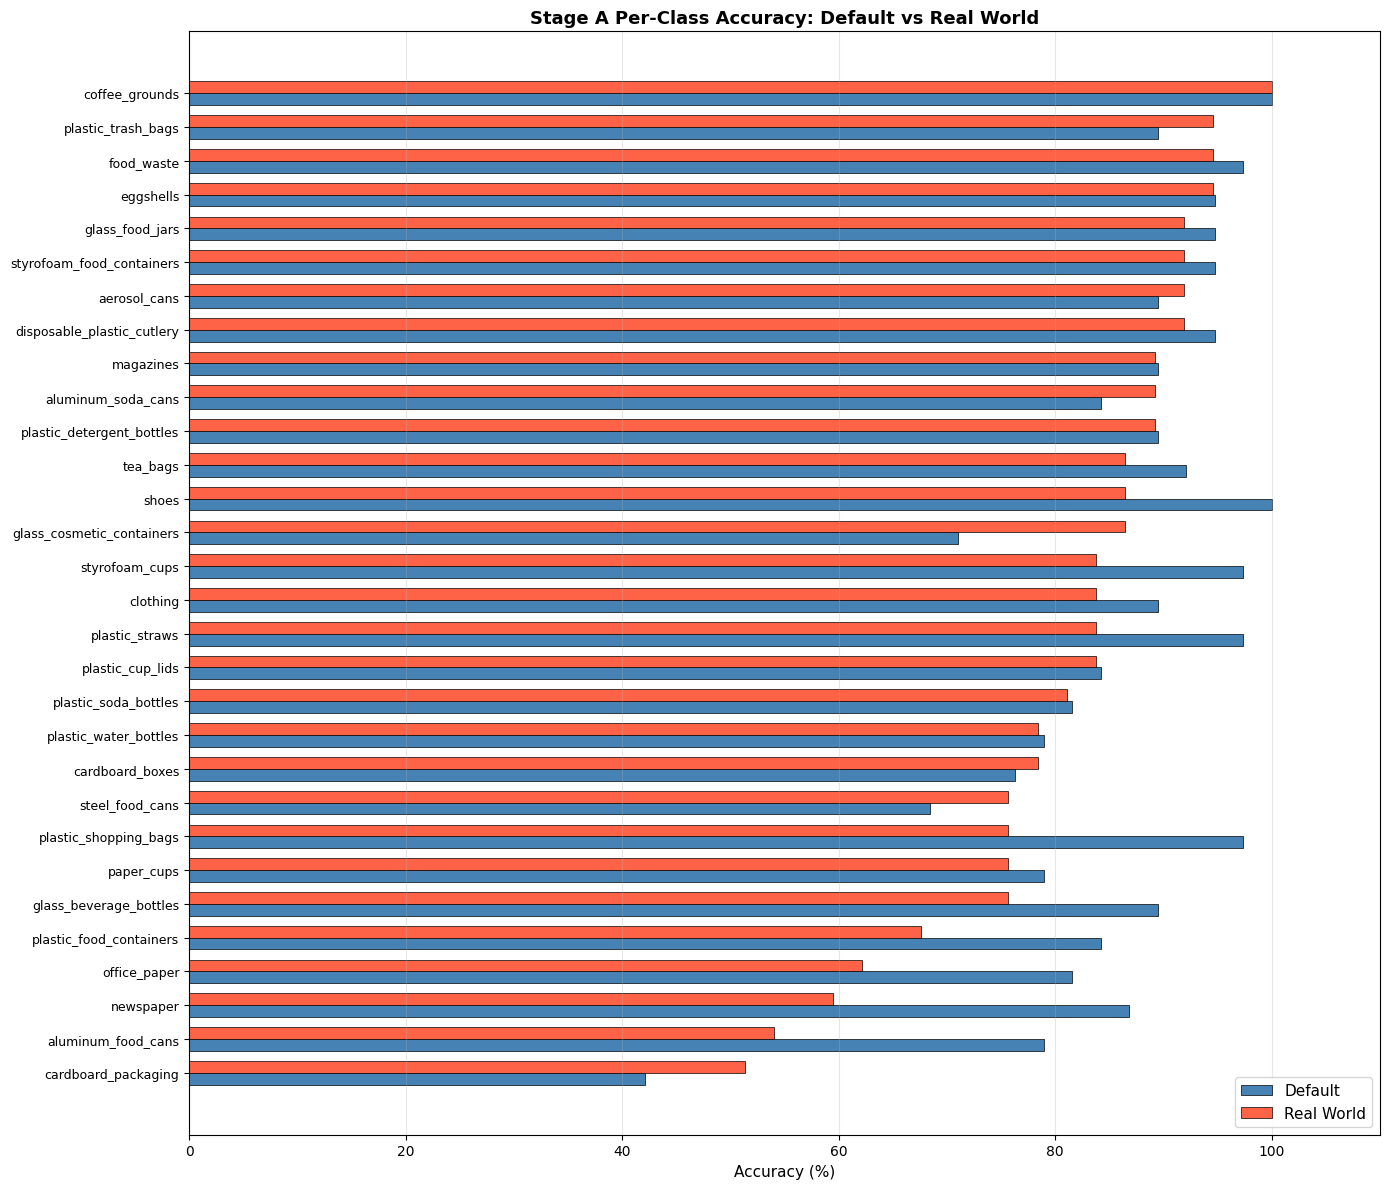

In [20]:
def evaluate_subcategory(model, dataset):
    preds, labels = [], []
    for images, label_batch in dataset:
        batch_preds = model.predict(images, verbose=0)
        preds.extend(np.argmax(batch_preds, axis=1))
        labels.extend(np.argmax(label_batch.numpy(), axis=1))  # Convert one-hot to integer class indices
    return np.array(preds), np.array(labels)

preds_default, labels_default = evaluate_subcategory(best_model_a, test_default_ds)
preds_real,    labels_real    = evaluate_subcategory(best_model_a, test_real_world_ds)

# Compute per-class accuracy for each subcategory
def per_class_acc(labels, preds):
    cm_sub  = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    row_sum = cm_sub.sum(axis=1)
    row_sum[row_sum == 0] = 1  # Avoid division by zero for any empty class
    return cm_sub.diagonal() / row_sum

acc_default = per_class_acc(labels_default, preds_default)
acc_real    = per_class_acc(labels_real,    preds_real)

# Print overall accuracy for each subcategory
print(f"Default    Overall Accuracy: {acc_default.mean():.4f}")
print(f"Real World Overall Accuracy: {acc_real.mean():.4f}")
print(f"Domain Gap:                 {acc_default.mean() - acc_real.mean():+.4f}")

# Print per-class comparison table sorted by real_world accuracy ascending
sorted_by_real = np.argsort(acc_real)
print(f"\n{'Class':<35} {'Default':>9} {'Real World':>11} {'Gap':>8}")
print("-" * 66)
for i in sorted_by_real:
    gap = acc_default[i] - acc_real[i]
    print(f"{class_names[i]:<35} {acc_default[i]:>9.4f} {acc_real[i]:>11.4f} {gap:>+8.4f}")

# Sort ascending so highest real_world accuracy is at the top of the chart
sort_idx       = np.argsort(acc_real)
sorted_names   = [class_names[i] for i in sort_idx]
sorted_default = [acc_default[i] * 100 for i in sort_idx]
sorted_real    = [acc_real[i]    * 100 for i in sort_idx]

y      = np.arange(len(sorted_names))
height = 0.35

fig, ax = plt.subplots(figsize=(14, 12))
ax.barh(y - height/2, sorted_default, height, label='Default',    color='steelblue', edgecolor='black', linewidth=0.5)
ax.barh(y + height/2, sorted_real,    height, label='Real World', color='tomato',    edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Stage A Per-Class Accuracy: Default vs Real World', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_default_vs_real_world.png', dpi=150, bbox_inches='tight')
plt.show()

Stage A achieves a **default subcategory accuracy of 86.1%** and a **real-world subcategory accuracy of 80.6%**, producing an overall domain gap of 5.5 percentage points. This is a relatively modest gap, suggesting the model has learned features that generalize reasonably well beyond studio conditions.

### 2.9 Confusion Matrices

We'll plot two confusion matrices for the Stage A: Base Waste Classifer. The first is a **class-level confusion matrix across all 30 waste categories**. Confusion matrices provide a detailed breakdown of model performance by comparing each predicted class against the actual ground truth label. A well-performing model will show a dark diagonal from top-left to bottom-right, indicating that most items are being classified correctly.

The second is a **disposal pathway confusion matrix collapsed across the 4 disposal pathways**. This is the more meaningful evaluation for EcoBin's real-world purpose. What ultimately matters is not whether the model identifies the exact object, but whether it routes that object to the correct bin. Evaluating at the pathway level also naturally absorbs errors between visually similar classes that share the same route, such as `cardboard_boxes` and `cardboard_packaging`, which both map to curbside recycling. A class-level error between these two is inconsequential in practice and should not count against the model.

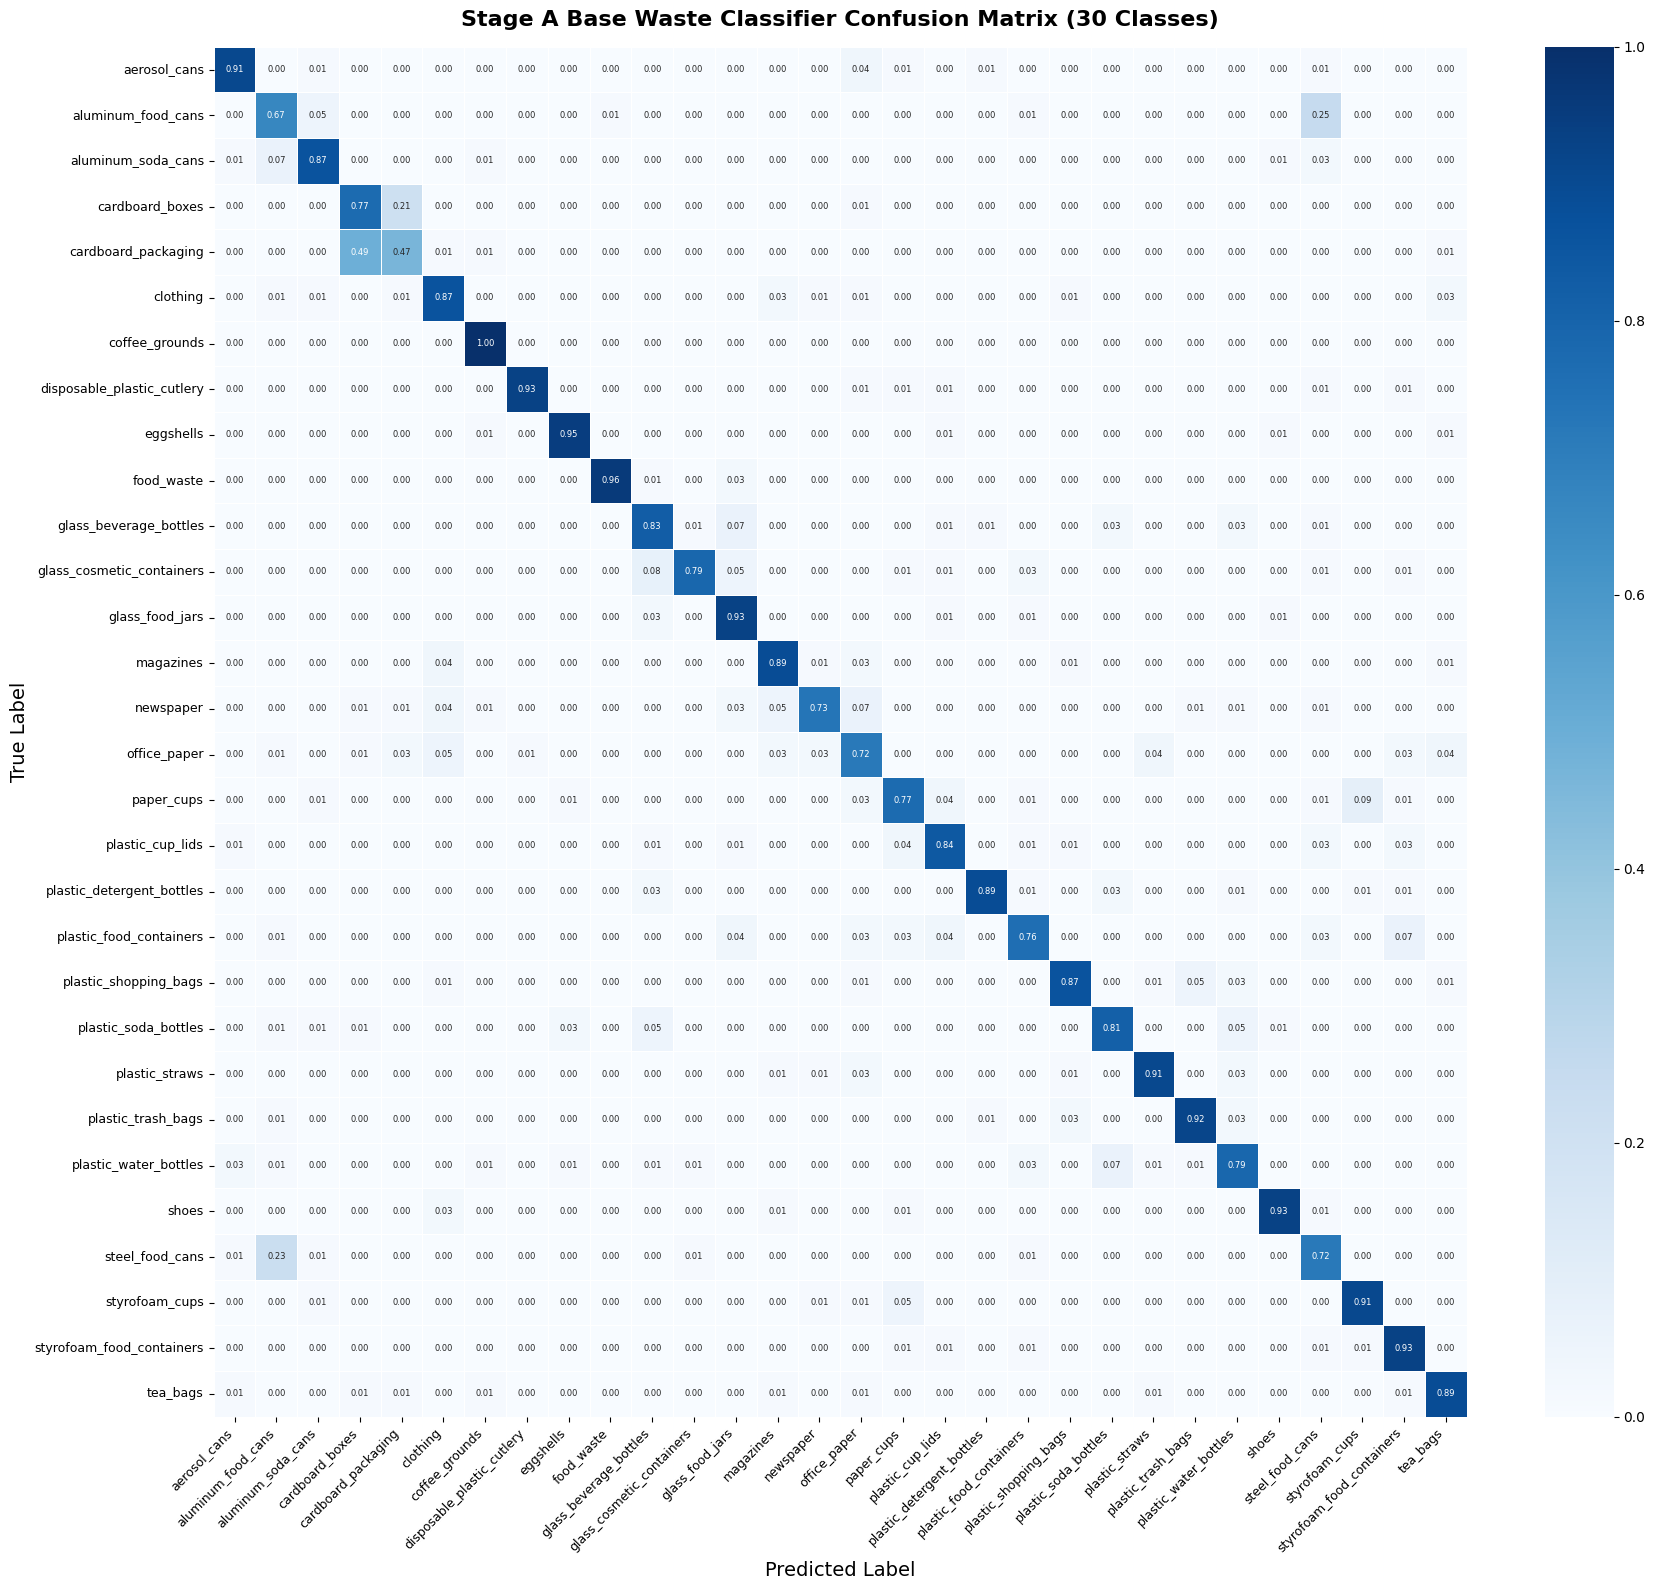

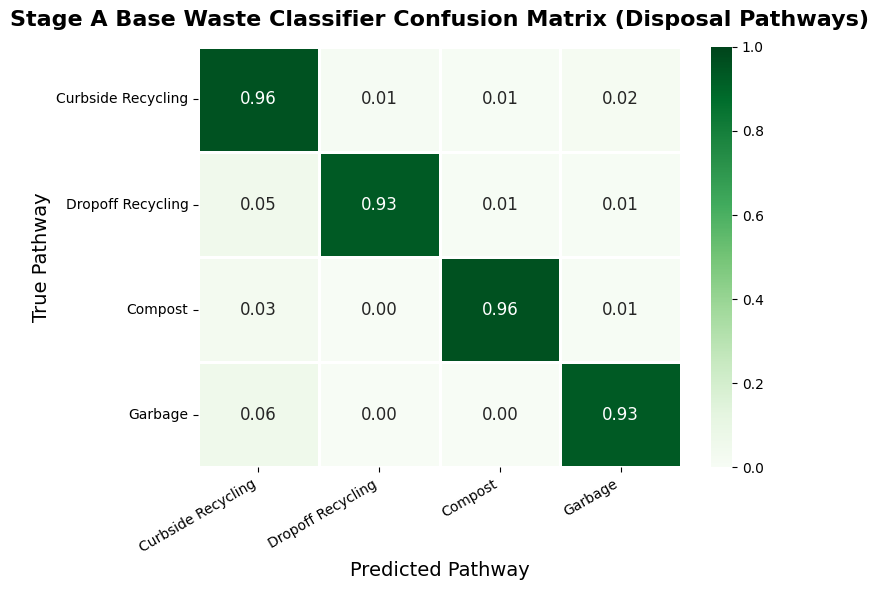

In [21]:
# ----------------------------
# Class-level Confusion Matrix
# ----------------------------

# Normalize class confusion matrix so each row sums to 1
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 6},
    vmin=0,
    vmax=1
)

# Print Class-level Confuson Matrix
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (30 Classes)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_confusion_matrix_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------
# Disposal Pathway Confusion Matrix
# ---------------------------------

# Build disposal pathway confusion matrix
PATHWAY_ORDER  = ['curbside_recycling', 'dropoff_recycling', 'compost', 'garbage']
PATHWAY_LABELS = [p.replace('_', ' ').title() for p in PATHWAY_ORDER]

pathway_true = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_labels]
pathway_pred = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_preds]

cm_pathway      = confusion_matrix(pathway_true, pathway_pred, labels=PATHWAY_ORDER)
cm_pathway_norm = cm_pathway.astype(float) / cm_pathway.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_pathway_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=PATHWAY_LABELS,
    yticklabels=PATHWAY_LABELS,
    ax=ax,
    linewidths=1,
    annot_kws={'size': 12},
    vmin=0,
    vmax=1
)

# Print Disposal Pathway Confusion Matrix
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (Disposal Pathways)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Pathway', fontsize=14)
ax.set_ylabel('True Pathway', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_confusion_matrix_pathways.png', dpi=150, bbox_inches='tight')
plt.show()

We can see that accuraccy has disposed signifantly with the disposal pathwya confusion matrix. This is expected becuase there are only 4 classes. We can see that when we group waste items together and decrease the number of classes of 30 to 4 there's a large jump in accuracy. Next, we will be plotting bar chart of the original accuracy for each class and the adjusted accuracy after accounting for disposal pathways. 

### 2.10 Plot Adjusted Accuracy Bar Chart

After conmparing the confusion matrices in the previous cell, we can determine that class-level accuracy penalizes the model equally for all misclassifications, regardless of whether the error actually results in an item being sent to the wrong bin. 

Adjusted accuracy corrects for this by marking a prediction as correct whenever the predicted class shares the same disposal pathway as the true class, regardless of whether the exact class label matches. In other words if adjusted accuracy doesn't mark the model as incorrect if it classifies `cardboard_box` as `cardboard_packaging` becuase both items go to curbside recyclign either way.  This adjusted approach would actually reflect genuine mistakes that would send an item to the wrong disposal pathway.

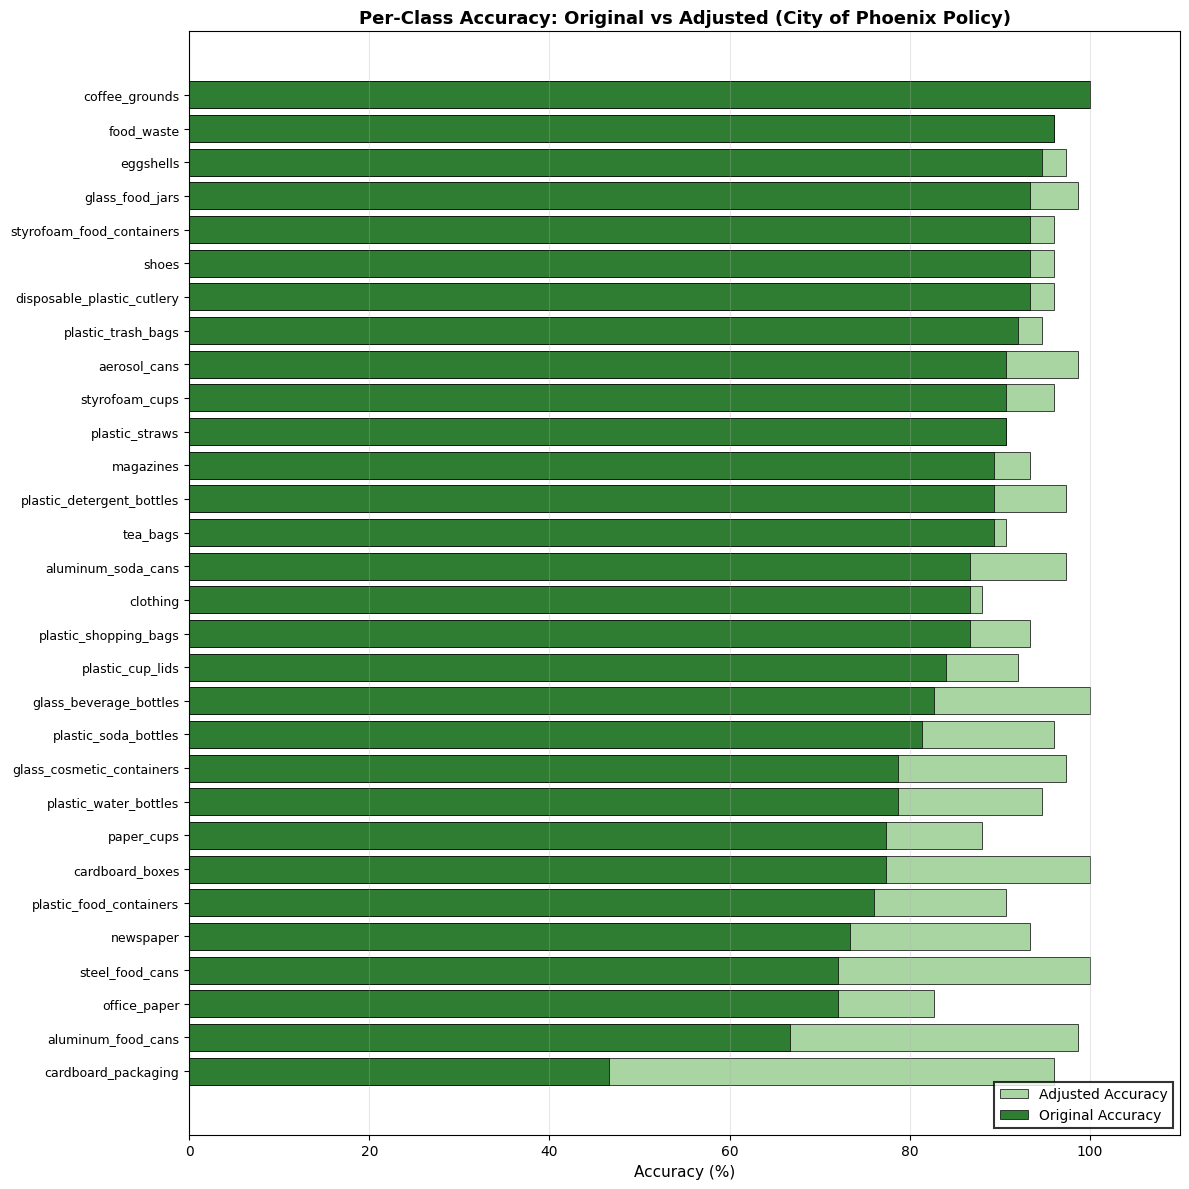

Original Accuracy: 0.8409
Adjusted Accuracy: 0.9498
Pathway Gain:      +0.1089


In [26]:
# Compute adjusted accuracy: correct if predicted class shares a disposal pathway with the true class
adjusted_correct = np.zeros(NUM_CLASSES)
class_counts     = np.zeros(NUM_CLASSES)

for true_idx, pred_idx in zip(all_labels, all_preds):
    true_pathway = DISPOSAL_MAP.get(class_names[true_idx], 'UNMAPPED')
    pred_pathway = DISPOSAL_MAP.get(class_names[pred_idx], 'UNMAPPED')
    class_counts[true_idx] += 1
    if true_pathway == pred_pathway:
        adjusted_correct[true_idx] += 1

adj_acc_per_class = adjusted_correct / class_counts

# Sort by original accuracy ascending so highest is at top of chart
sort_idx     = np.argsort(per_class_accuracy)
sorted_names = [class_names[i] for i in sort_idx]
sorted_orig  = [per_class_accuracy[i] * 100 for i in sort_idx]
sorted_adj   = [adj_acc_per_class[i]  * 100 for i in sort_idx]

y = np.arange(len(sorted_names))

fig, ax = plt.subplots(figsize=(12, 12))

# Draw adjusted accuracy bars first so original bars sit on top
ax.barh(y, sorted_adj,  color='#A8D5A2', label='Adjusted Accuracy', edgecolor='black', linewidth=0.5)
ax.barh(y, sorted_orig, color='#2E7D32', label='Original Accuracy',  edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy: Original vs Adjusted (City of Phoenix Policy)', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

legend = ax.legend(
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fancybox=False,
    fontsize=10
)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_adjusted_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overall accuracy comparison
overall_orig = per_class_accuracy.mean()
overall_adj  = adjusted_correct.sum() / class_counts.sum()
print(f"Original Accuracy: {overall_orig:.4f}")
print(f"Adjusted Accuracy: {overall_adj:.4f}")
print(f"Pathway Gain:      {overall_adj - overall_orig:+.4f}")

The bar chart reveals the adjustment to disposal pathways increase accuracy by over 10%, bringing our new accuracy to **94.18%**.

## Step 3: Prepare Synthetic Recyclable Contamination Dataset

Stage B requires a training dataset that the AlistairKing dataset does not provide: recyclable images labelled as either clean or contaminated. We build this dataset entirely from the recyclable images already in the Stage A source data, without collecting any new images.

We record each source image as-is and label it **clean**. We then generate one contaminated copy per source image at a severity level (**light**, **medium** or **heavy**) that is pre-assigned before generation begins. Severity levels are distributed evenly across the full image pool so each level accounts for exactly one third of the contaminated set. This produces a final dataset of 10,500 clean images and 10,500 contaminated images, balanced 1:1.

We apply contamination by compositing texture patches from a separate contamination texture library onto each object. A U2-Net segmentation model isolates the foreground object so that no contamination bleeds onto the background.

### 3.1 Install Dependencies

`rembg` uses a U2-Net neural network to separate the foreground object from the background in each recyclable image. This produces an object mask that ensures the contamination texture is only placed on the object surface instead of elsewhere on the image.

In [98]:
!pip install "rembg[gpu]" pillow-avif-plugin -q
!pip install --force-reinstall "scipy>=1.14.0" -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 48.7 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 52.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 104.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 26.6 MB/s eta 0:00:0000:01:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires numba<0.63,>=0.6

### 3.2 Import Libraries

In [99]:
import io
import math

from rembg import remove, new_session
from scipy import ndimage

from PIL import ImageFilter
from tqdm import tqdm


### 3.3 Initialise the rembg Session

Without a session argument, `rembg` reloads the U2-Net ONNX model from disk every time `remove()` is called. With over 10,500 images to generate this adds up to thousands of redundant model loads. We create one session here and reuse it throughout the pipeline to eliminate that overhead. With `rembg[gpu]` installed and a GPU accelerator enabled, ONNX Runtime routes inference through CUDA automatically.

In [100]:
REMBG_SESSION = new_session('u2netp')
print("U2-Net session initialised")


U2-Net session initialised


### 3.4 Configure Paths and Constants

`CONTAMINATION_LEVELS` maps each severity label to the number of texture patches applied to the object:

| Level | Patches | Description |
|---|---|---|
| light | 1 | A single texture patch applied to one region of the object |
| medium | 2 | Two patches applied to separate regions of the object |
| heavy | 3 | Three patches covering multiple regions of the object |

In [101]:
# Set this to the path of your zip file in Google Drive
TEXTURE_ZIP     = Path("YOUR_DRIVE_PATH/Contamination Textures Dataset.zip")
TEXTURE_EXTRACT = Path("/content/texture_dataset")

# Unzip into TEXTURE_EXTRACT the first time; skip if already extracted
if not TEXTURE_EXTRACT.exists():
    print("Extracting texture dataset...")
    with zipfile.ZipFile(TEXTURE_ZIP, 'r') as zf:
        zf.extractall(TEXTURE_EXTRACT)
    print("Extraction complete.")

TEXTURE_PATH  = TEXTURE_EXTRACT / "Contamination Textures Dataset" / "textures"
STAGE_B_PATH  = Path("/content/Stage B Dataset")
TEXTURE_CACHE = Path("/content/texture_cache")
DATASET_ROOT  = Path("/content/Synthetic Recyclable Contamination Dataset")

# Number of source images stratified-sampled across the recyclable classes
SAMPLE_SIZE = 1000

CONTAMINATION_LEVELS = {
    'light':  1,
    'medium': 2,
    'heavy':  3,
}

# Derived from DISPOSAL_MAP: only recyclable classes, with EXCLUDED_CLASSES removed
RECYCLABLE_CLASSES = [
    cls for cls, pathway in DISPOSAL_MAP.items()
    if pathway in ('curbside_recycling', 'dropoff_recycling')
    and cls not in EXCLUDED_CLASSES
]


### 3.5 Build the Contamination Texture Pool

#### 3.5.1 Discover Contaminant Types and Texture Images

We build the texture pool by scanning the contamination texture library directory. Each subdirectory represents one contaminant type and contains five source PNG texture images. The pool is a dictionary mapping each contaminant type name to the list of file paths for its textures.

This cell prints each contaminant type and the number of images within each contaminant type.

In [102]:
def build_texture_pool(texture_path: Path) -> dict:
    pool = {}
    for contaminant_dir in sorted(texture_path.iterdir()):
        if not contaminant_dir.is_dir():
            continue
        textures = sorted(
            f for f in contaminant_dir.iterdir()
            if f.suffix.lower() == '.png'
            and '_nobg' not in f.stem
        )
        if textures:
            pool[contaminant_dir.name] = textures
    return pool

texture_pool = build_texture_pool(TEXTURE_PATH)

print(f"Discovered {len(texture_pool)} contaminant types")
for contaminant, textures in texture_pool.items():
    print(f"  {contaminant:<25} {len(textures)} images")


Discovered 8 contaminant types
  coffee_stains             5 images
  condiment_residue         5 images
  dirt                      5 images
  food_residue              5 images
  grease                    5 images
  mold                      5 images
  paint                     5 images
  wet_paper_pulp            5 images


#### 3.5.2 Display Texture Pool Summary

This cell prints a full inventory of the texture pool, listing each file under its contaminant type. We can confirm that all expected texture files were discovered and that no files were skipped.

In [103]:
total = sum(len(v) for v in texture_pool.values())
print(f"Contamination Texture Library")
print(f"{'='*50}")
for contaminant, textures in texture_pool.items():
    print(f"\n  {contaminant}")
    for t in textures:
        print(f"    {t.name}")
print(f"\n{'='*50}")
print(f"Total: {len(texture_pool)} types, {total} images")


Contamination Texture Library

  coffee_stains
    coffee_stain_1.png
    coffee_stain_2.png
    coffee_stain_3.png
    coffee_stain_4.png
    coffee_stain_5.png

  condiment_residue
    condiment_residue_1.png
    condiment_residue_2.png
    condiment_residue_3.png
    condiment_residue_4.png
    condiment_residue_5.png

  dirt
    dirt_1.png
    dirt_2.png
    dirt_3.png
    dirt_4.png
    dirt_5.png

  food_residue
    food_residue_1.png
    food_residue_2.png
    food_residue_3.png
    food_residue_4.png
    food_residue_5.png

  grease
    grease_1.png
    grease_2.png
    grease_3.png
    grease_4.png
    grease_5.png

  mold
    mold_1.png
    mold_2.png
    mold_3.png
    mold_4.png
    mold_5.png

  paint
    paint_stain_1.png
    paint_stain_2.png
    paint_stain_3.png
    paint_stain_4.png
    paint_stain_5.png

  wet_paper_pulp
    wet_paper_pulp_1.png
    wet_paper_pulp_2.png
    wet_paper_pulp_3.png
    wet_paper_pulp_4.png
    wet_paper_pulp_5.png

Total: 8 types, 40 ima

Here we cann see there are a total of 40 images across the 8 different types of contaminant textures.

### 3.6 Define Image Processing Functions

#### 3.6.1 Object Segmentation

`get_object_mask` runs `rembg` on a source image to produce a soft float mask that identifies the foreground object. Pixel values close to 1.0 are confidently part of the object. Pixel values close to 0.0 are background.

Two post-processing steps clean up the raw mask before it is used for compositing:

1. **Morphological closing** fills small holes that rembg may leave inside the object, for example through transparent or reflective surfaces on glass bottles or plastic bags.
2. **Gaussian blur** feathers the mask edges so composited contamination fades naturally at the object boundary instead of producing a hard cutline.

In [105]:
def get_object_mask(img: np.ndarray) -> np.ndarray:
    buf = io.BytesIO()
    Image.fromarray(img).save(buf, format='PNG')
    output = remove(buf.getvalue(), session=REMBG_SESSION)
    alpha  = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))[:, :, 3]
    alpha  = alpha.astype(np.float32) / 255.0
    # Fill small interior holes left by transparent or reflective surfaces
    binary = ndimage.binary_closing(
        alpha > 0.5, structure=np.ones((5, 5))
    ).astype(np.float32)
    # Feather edges so composited contamination fades at the object boundary
    return ndimage.gaussian_filter(binary, sigma=2)


#### 3.6.2 Texture Loading

`load_texture` loads a contamination texture as an RGBA array and removes its background before compositing. `rembg` is used for background removal, which handles any background colour robustly.

The loading strategy depends on file format. For PNG files that already contain alpha transparency the file is loaded directly. For all other cases, including fully opaque PNGs and JPEG or AVIF files that cannot store transparency, `rembg` is run to isolate the contaminant texture from its background.

The processed RGBA is cached as a `_nobg.png` file in `/kaggle/working/texture_cache/` since `/kaggle/input` is read-only. Background removal only runs once per texture; subsequent runs load from cache.

In [106]:
def load_texture(texture_path: Path) -> np.ndarray:
    # Cache lives in /content (writable Colab scratch space)
    cache_path = TEXTURE_CACHE / texture_path.parent.name / (texture_path.stem + '_nobg.png')
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        return np.array(Image.open(cache_path).convert('RGBA'))

    ext           = texture_path.suffix.lower()
    needs_removal = True

    if ext == '.png':
        rgba = np.array(Image.open(texture_path).convert('RGBA'))
        # If the alpha channel already has transparency, use it directly
        if rgba[:, :, 3].min() < 255:
            needs_removal = False

    if needs_removal:
        with open(texture_path, 'rb') as f:
            output = remove(f.read(), session=REMBG_SESSION)
        rgba = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))

    Image.fromarray(rgba).save(cache_path)
    return rgba


#### 3.6.3 Texture Patch Application

`apply_texture_patch` composites a single contamination texture patch onto the object region of a base image. The texture is randomly augmented before placement so the same source texture file produces a visually distinct patch every time it is used.

The final composite is controlled by three masks multiplied together into a single weight map:

| Mask | Source | Purpose |
|---|---|---|
| Texture alpha | The texture's own RGBA alpha channel | Preserves the stain or residue shape |
| Object mask | Output of `get_object_mask` | Restricts the composite to the foreground object |
| Alpha scalar | Random float in [0.45, 0.75] | Controls the overall opacity of the contamination effect |

The anchor point for each patch is sampled uniformly at random from within the object region, which ensures patches land on the object surface rather than at a fixed location.

In [107]:
def apply_texture_patch(
    base_img:     np.ndarray,
    texture_rgba: np.ndarray,
    object_mask:  np.ndarray,
    alpha:        float = 0.6,
) -> np.ndarray:
    H, W = base_img.shape[:2]

    # Sample a random anchor point from within the object region
    obj_ys, obj_xs = np.where(object_mask > 0.3)
    if len(obj_ys) == 0:
        return base_img
    idx = random.randint(0, len(obj_ys) - 1)
    cy, cx = int(obj_ys[idx]), int(obj_xs[idx])

    # Augment the texture
    tex = Image.fromarray(texture_rgba, 'RGBA')
    tex = tex.rotate(random.uniform(0, 360), expand=True)
    scale = random.uniform(0.25, 0.60)
    tex = tex.resize((max(1, int(W * scale)), max(1, int(H * scale))), Image.LANCZOS)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_TOP_BOTTOM)

    tex_arr = np.array(tex)
    th, tw  = tex_arr.shape[:2]

    # Compute placement coordinates centered on the anchor
    x1, y1 = cx - tw // 2, cy - th // 2
    x2, y2 = x1 + tw, y1 + th

    # Clip to image bounds
    ix1, iy1 = max(0, x1), max(0, y1)
    ix2, iy2 = min(W, x2), min(H, y2)

    if ix2 <= ix1 or iy2 <= iy1:
        return base_img

    sx1 = ix1 - x1
    sy1 = iy1 - y1
    sx2 = sx1 + (ix2 - ix1)
    sy2 = sy1 + (iy2 - iy1)
    tex_slice = tex_arr[sy1:sy2, sx1:sx2]

    # Three-way weight: texture alpha x object mask x opacity scalar
    tex_a  = tex_slice[:, :, 3].astype(np.float32) / 255.0
    obj_a  = object_mask[iy1:iy2, ix1:ix2]
    weight = tex_a * obj_a * alpha

    # Composite
    result  = base_img.astype(np.float32)
    region  = result[iy1:iy2, ix1:ix2]
    tex_rgb = tex_slice[:, :, :3].astype(np.float32)
    result[iy1:iy2, ix1:ix2] = (
        region * (1 - weight[..., np.newaxis]) + tex_rgb * weight[..., np.newaxis]
    )
    return np.clip(result, 0, 255).astype(np.uint8)


### 3.7 Build the Output Directory Structure

We only write the contaminated images to disk during generation. Clean images are referenced directly from the Stage A source dataset in the manifest. Each contaminated subdirectory encodes both the contaminant type and the severity level.

```
Stage B Dataset/
└── contaminated/
    ├── coffee_stains/
    │   ├── light/
    │   ├── medium/
    │   └── heavy/
    └── ... (one folder per contaminant type)
```

Any existing Stage B Dataset output is cleared before the pipeline runs to ensure a clean state.

In [108]:
if STAGE_B_PATH.exists():
    shutil.rmtree(STAGE_B_PATH)
    print("Cleared existing Stage B Dataset directory")

# Clean output directories: one folder per recyclable class
for cls in RECYCLABLE_CLASSES:
    (STAGE_B_PATH / 'clean' / cls).mkdir(parents=True, exist_ok=True)

# Contaminated output directories: contaminated/<contaminant_type>/<source_class>/
for contaminant in texture_pool:
    for cls in RECYCLABLE_CLASSES:
        (STAGE_B_PATH / 'contaminated' / contaminant / cls).mkdir(parents=True, exist_ok=True)

print("Output directory structure created")
print(f"  {STAGE_B_PATH / 'clean'}")
print(f"  {STAGE_B_PATH / 'contaminated'}")


Cleared existing Stage B Dataset directory
Output directory structure created
  /kaggle/working/Stage B Dataset/contaminated


### 3.8 Run the Generation Pipeline

We stratified-sample a fixed number of source images across the recyclable classes (the count is controlled by `SAMPLE_SIZE`), then generate **9 copies per source**: 1 clean copy plus 1 copy for each of the 8 contamination subgroups. Stratified sampling guarantees every recyclable class contributes proportionally to its share of the source pool.

For each (source, contaminant_type) pair we pre-assign a severity level (light, medium, or heavy) so the global distribution of severities is balanced at roughly 33% per level. Pre-assignment is shuffled across all 8,000 pairs so no class or contaminant type is biased toward a particular level.

For each source image the pipeline executes:

1. **Load and resize** the source image to `IMG_SIZE x IMG_SIZE`.
2. **Save the clean copy** into `Stage B Dataset/clean/<source_class>/`.
3. **Compute the object mask once** with rembg -- the same mask is reused for all 8 contamination copies of this source so we do not pay the rembg cost 8 times per source.
4. **Generate 8 contaminated copies**, one per contamination subgroup. Each copy applies N texture patches at the pre-assigned severity (`light=1`, `medium=2`, `heavy=3`) and is saved into `Stage B Dataset/contaminated/<contaminant_type>/<source_class>/`.


In [109]:
# Clear texture cache so load_texture rebuilds it with background removal applied
import shutil
if TEXTURE_CACHE.exists():
    shutil.rmtree(TEXTURE_CACHE)
    print(f"Cleared texture cache: {TEXTURE_CACHE}")
else:
    print("No cache to clear.")


Cleared texture cache: /kaggle/working/texture_cache


In [117]:
records           = []
contaminant_types = sorted(texture_pool.keys())

# Collect all source images across every recyclable class (excludes EXCLUDED_CLASSES)
class_to_images = {}
for class_name in RECYCLABLE_CLASSES:
    class_dir = DATASET_PATH / class_name
    if not class_dir.exists():
        print(f"WARNING: {class_name} not found in dataset, skipping")
        continue
    imgs = [(class_name, p) for p in class_dir.rglob('*') if p.is_file()]
    class_to_images[class_name] = imgs

# Stratified sample SAMPLE_SIZE source images proportionally across classes
total_avail   = sum(len(v) for v in class_to_images.values())
sampled       = []
rng_sample    = random.Random(SEED)
for class_name, imgs in class_to_images.items():
    n_take = max(1, round(SAMPLE_SIZE * len(imgs) / total_avail))
    n_take = min(n_take, len(imgs))
    sampled.extend(rng_sample.sample(imgs, n_take))

# Trim or shuffle down to land exactly on SAMPLE_SIZE
rng_sample.shuffle(sampled)
sampled = sampled[:SAMPLE_SIZE]
n_sources = len(sampled)

# Pre-assign severity levels across all (source, contaminant) pairs so the global
# distribution is roughly 33% light / 33% medium / 33% heavy
n_pairs    = n_sources * len(contaminant_types)
per_level  = math.ceil(n_pairs / 3)
level_pool = (['light'] * per_level + ['medium'] * per_level + ['heavy'] * per_level)[:n_pairs]
rng_levels = random.Random(SEED + 1)
rng_levels.shuffle(level_pool)

# Build (source_idx, contaminant) -> level lookup
pair_to_level = {}
pair_idx = 0
for src_idx in range(n_sources):
    for ctm in contaminant_types:
        pair_to_level[(src_idx, ctm)] = level_pool[pair_idx]
        pair_idx += 1

print(f"Source images sampled: {n_sources:,}")
print(f"  Contamination pairs : {n_pairs:,}  ({len(contaminant_types)} types x {n_sources} sources)")
print(f"  Level distribution  : {Counter(level_pool)}")
print(f"  Expected total      : {n_sources + n_pairs:,}  ({n_sources:,} clean + {n_pairs:,} contaminated)\n")

for src_idx, (class_name, img_path) in enumerate(tqdm(sampled, desc="Generating")):
    source_stem = f"{img_path.parent.name}_{img_path.stem}"

    # Load and resize once -- both the clean copy and all 8 contaminated copies
    # start from this array
    base_img = np.array(
        Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    )

    # Run rembg once per source so all 8 contaminated copies share the same mask
    mask = get_object_mask(base_img)

    # Save the clean copy
    clean_path = STAGE_B_PATH / 'clean' / class_name / f"{source_stem}.png"
    Image.fromarray(base_img).save(clean_path, format='PNG')

    records.append({
        'image_path':   str(clean_path),
        'label':        'clean',
        'subgroup':     'none',
        'level':        'none',
        'source_class': class_name,
        'source_stem':  source_stem,
    })

    # Generate one contaminated copy per contamination subgroup
    for ctm in contaminant_types:
        level              = pair_to_level[(src_idx, ctm)]
        n_patches          = CONTAMINATION_LEVELS[level]
        available_textures = texture_pool[ctm]

        result_img = base_img.copy()
        for _ in range(n_patches):
            tex_path   = random.choice(available_textures)
            texture    = load_texture(tex_path)
            alpha      = random.uniform(0.45, 0.75)
            result_img = apply_texture_patch(result_img, texture, mask, alpha=alpha)

        cont_path = (STAGE_B_PATH / 'contaminated' / ctm / class_name /
                     f"{source_stem}_{level}.png")
        Image.fromarray(result_img).save(cont_path, format='PNG')

        records.append({
            'image_path':   str(cont_path),
            'label':        'contaminated',
            'subgroup':     ctm,
            'level':        level,
            'source_class': class_name,
            'source_stem':  source_stem,
        })

print(f"\nGeneration complete: {n_sources:,} source images -> {len(records):,} total images")


Source images : 10,500
  light       : 3,500
  medium      : 3,500
  heavy       : 3,500
Expected total: 21,000  (10,500 clean + 10,500 contaminated)



Generating:   0%|          | 0/10500 [00:00<?, ?it/s]/tmp/ipykernel_57/3011236250.py:17: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  tex = Image.fromarray(texture_rgba, 'RGBA')
Generating: 100%|██████████| 10500/10500 [15:49<00:00, 11.06it/s]


Generation complete: 10,500 source images -> 21,000 total images


### 3.9 Build the Stage B Manifest

The manifest is a CSV file that records every image in the dataset alongside its full label information. The `source_stem` column groups together all 9 copies generated from the same source image and is the key the Step 4 dataloader uses to split train/val/test by source rather than by random row -- this is what prevents leakage where the same object would appear in two different splits.

| Column | Values | Description |
|---|---|---|
| image_path | string | Absolute path to the image file |
| label | `clean`, `contaminated` | Binary collapse of the 9-class target |
| subgroup | contaminant type or `none` | One of 8 contaminant types (or `none` for clean) |
| level | `light`, `medium`, `heavy` or `none` | Contamination severity |
| source_class | waste class name | Original Stage A waste class the image came from |
| source_stem | string | Unique identifier shared across the 9 copies of a single source image |


In [118]:
df_stage_b = pd.DataFrame(records)

manifest_path = STAGE_B_PATH / 'stage_b_manifest.csv'
df_stage_b.to_csv(manifest_path, index=False)

print(f"Manifest saved to {manifest_path}")
print(f"Total images: {len(df_stage_b):,}")
print(f"\nSample rows:")
print(df_stage_b.head(8).to_string(index=False))


Manifest saved to /kaggle/working/Stage B Dataset/stage_b_manifest.csv
Total images: 21,000

Sample rows:
                                                                                                  image_path        label       subgroup  level         source_class
                              /kaggle/working/Stage B Dataset/clean/plastic_soda_bottles/default_Image_1.png        clean           none   none plastic_soda_bottles
   /kaggle/working/Stage B Dataset/contaminated/plastic_soda_bottles/default_Image_1_food_residue_medium.png contaminated   food_residue medium plastic_soda_bottles
                            /kaggle/working/Stage B Dataset/clean/plastic_soda_bottles/default_Image_213.png        clean           none   none plastic_soda_bottles
/kaggle/working/Stage B Dataset/contaminated/plastic_soda_bottles/default_Image_213_wet_paper_pulp_heavy.png contaminated wet_paper_pulp  heavy plastic_soda_bottles
                            /kaggle/working/Stage B Dataset/clean/pla

### 3.10 Audit the Dataset

With the manifest built, we can audit the dataset to verify that the generation pipeline produced the expected number of images per label, subgroup and severity level.

#### 3.10.1 Label Distribution

This cell prints the total image count split by binary label. The clean and contaminated sets should be in a 1:1 ratio (10.5K images for each category). Each source image produces one clean entry in the manifest and one contaminated copy, with the contaminated set split evenly across the three severity levels.

In [119]:
label_counts = df_stage_b['label'].value_counts()

print("Label Distribution")
print("=" * 40)
for label, count in label_counts.items():
    pct = count / len(df_stage_b) * 100
    print(f"  {label:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(df_stage_b):>7,}")

Label Distribution
  clean                 10,500  (50.0%)
  contaminated          10,500  (50.0%)
----------------------------------------
  Total                 21,000


#### 3.10.2 Subgroup Distribution

This cell prints the image count per contaminant type within the contaminated set. Because contaminant type is assigned uniformly at random per source image, each type should receive approximately equal representation (roughly 1/N of the contaminated set, where N is the number of contaminant types).

In [120]:
contaminated_df = df_stage_b[df_stage_b['label'] == 'contaminated']
subgroup_counts = contaminated_df['subgroup'].value_counts().sort_index()

print("Subgroup Distribution (contaminated images only)")
print("=" * 50)
for subgroup, count in subgroup_counts.items():
    pct = count / len(contaminated_df) * 100
    print(f"  {subgroup:<28} {count:>7,}  ({pct:.1f}%)")
print("-" * 50)
print(f"  {'Total':<28} {len(contaminated_df):>7,}")

Subgroup Distribution (contaminated images only)
  coffee_stains                  1,304  (12.4%)
  condiment_residue              1,352  (12.9%)
  dirt                           1,330  (12.7%)
  food_residue                   1,289  (12.3%)
  grease                         1,318  (12.6%)
  mold                           1,292  (12.3%)
  paint                          1,324  (12.6%)
  wet_paper_pulp                 1,291  (12.3%)
--------------------------------------------------
  Total                         10,500


#### 3.10.3 Level Distribution

This cell prints the image count per severity level within the contaminated set. Each level is pre-assigned once per source image so the three levels should have identical counts.

In [121]:
level_counts = contaminated_df['level'].value_counts()
level_order  = ['light', 'medium', 'heavy']

print("Level Distribution (contaminated images only)")
print("=" * 40)
for level in level_order:
    count = level_counts.get(level, 0)
    pct   = count / len(contaminated_df) * 100
    print(f"  {level:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(contaminated_df):>7,}")

Level Distribution (contaminated images only)
  light                  3,500  (33.3%)
  medium                 3,500  (33.3%)
  heavy                  3,500  (33.3%)
----------------------------------------
  Total                 10,500


#### 3.10.4 Summary Bar Charts

This cell plots the label, subgroup and level distributions side by side and saves the figure to `Stage B Dataset/stage_b_audit.png`.

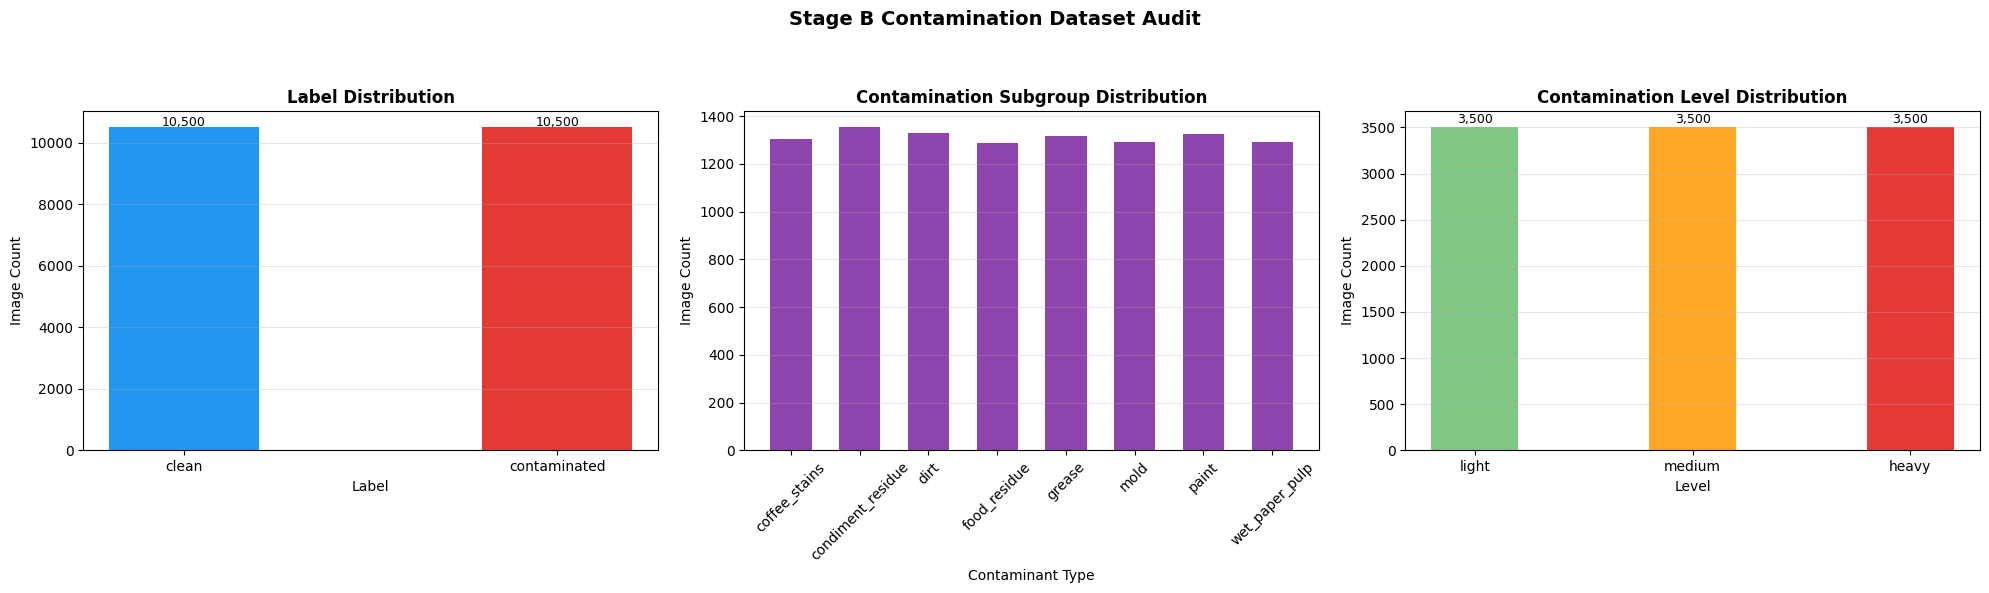

Saved to /kaggle/working/Stage B Dataset/stage_b_audit.png


In [122]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Label distribution
axes[0].bar(label_counts.index, label_counts.values, color=['#2196F3', '#E53935'], width=0.4)
axes[0].set_title('Label Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Label', fontsize=10)
axes[0].set_ylabel('Image Count', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

# Subgroup distribution
axes[1].bar(subgroup_counts.index, subgroup_counts.values, color='#8E44AD', width=0.6)
axes[1].set_title('Contamination Subgroup Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Contaminant Type', fontsize=10)
axes[1].set_ylabel('Image Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Level distribution
level_vals   = [level_counts.get(l, 0) for l in level_order]
level_colors = ['#81C784', '#FFA726', '#E53935']
axes[2].bar(level_order, level_vals, color=level_colors, width=0.4)
axes[2].set_title('Contamination Level Distribution', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Level', fontsize=10)
axes[2].set_ylabel('Image Count', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)
for i, count in enumerate(level_vals):
    axes[2].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

plt.suptitle('Stage B Contamination Dataset Audit', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])

audit_chart_path = STAGE_B_RESULTS_PATH / 'dataset_audit.png'
plt.savefig(audit_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {audit_chart_path}")


#### 3.10.5 Visual Sample Audit

This cell randomly samples five matched clean/contaminated pairs and displays them in two rows. Each image is labelled with its binary label, subgroup and severity level so the compositing quality can be inspected visually.

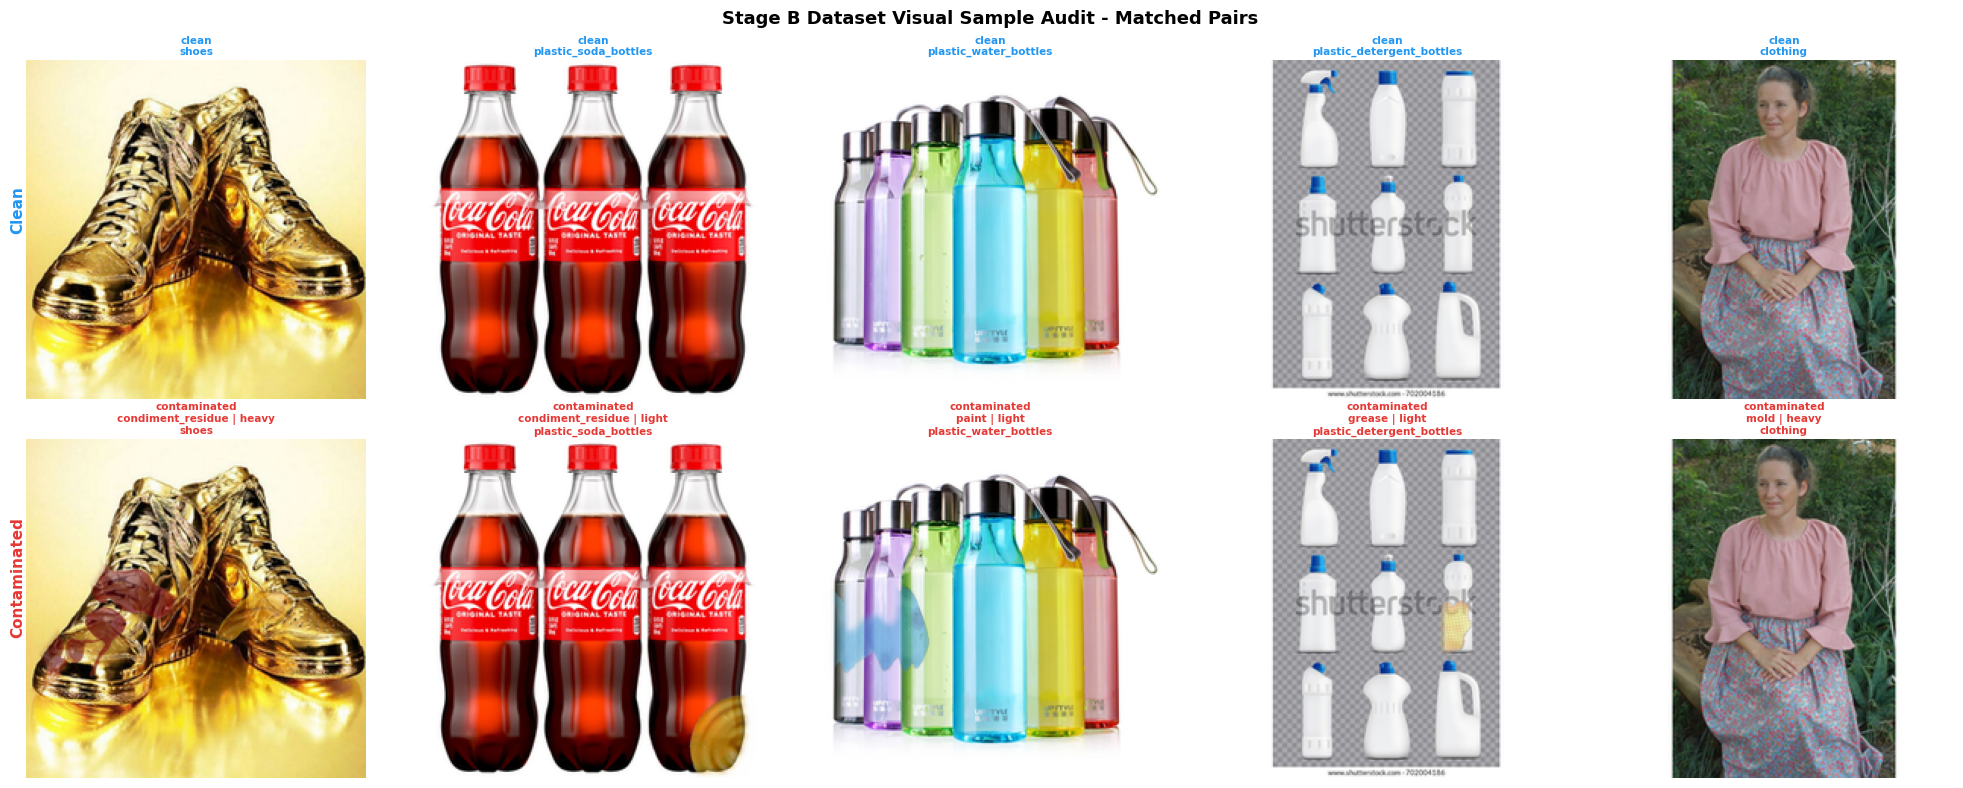

Saved to /kaggle/working/Stage B Dataset/stage_b_visual_audit.png


In [123]:
clean_rows = df_stage_b[df_stage_b['label'] == 'clean'].reset_index(drop=True)
cont_rows  = df_stage_b[df_stage_b['label'] == 'contaminated'].reset_index(drop=True)

n_pairs    = min(5, len(clean_rows), len(cont_rows))
safe_range = range(min(len(clean_rows), len(cont_rows)))
sample_idx = random.sample(list(safe_range), n_pairs)
pairs      = [(clean_rows.iloc[i], cont_rows.iloc[i]) for i in sample_idx]

fig, axes = plt.subplots(2, n_pairs, figsize=(4 * n_pairs, 8))
if n_pairs == 1:
    axes = axes.reshape(2, 1)

for col, (clean_row, cont_row) in enumerate(pairs):
    axes[0, col].imshow(Image.open(clean_row['image_path']).convert('RGB'))
    axes[0, col].axis('off')
    axes[0, col].set_title(f"clean
{clean_row['source_class']}", fontsize=7.5,
                            color='#2196F3', fontweight='bold', pad=4)

    axes[1, col].imshow(Image.open(cont_row['image_path']).convert('RGB'))
    axes[1, col].axis('off')
    axes[1, col].set_title(
        f"contaminated
{cont_row['subgroup']} | {cont_row['level']}
{cont_row['source_class']}",
        fontsize=7.5, color='#E53935', fontweight='bold', pad=4
    )

fig.text(0.01, 0.73, 'Clean',        va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#2196F3')
fig.text(0.01, 0.27, 'Contaminated', va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#E53935')

plt.suptitle('Stage B Dataset Visual Sample Audit - Matched Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()

visual_audit_path = STAGE_B_RESULTS_PATH / 'visual_sample_audit.png'
plt.savefig(visual_audit_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {visual_audit_path}")


### 3.11 Save Synthetic Recyclable Contamination Dataset

This cell assembles the final packaged dataset. Clean and contaminated images are copied into a 9-class directory structure under `Synthetic Recyclable Contamination Dataset/images/`:

```
Synthetic Recyclable Contamination Dataset/
|-- stage_b_manifest.csv
\\-- images/
    |-- clean/
    |   |-- aluminum_food_cans/
    |   \\-- ... (other recyclable classes)
    \\-- contaminated/
        |-- coffee_stains/
        |   |-- aluminum_food_cans/
        |   \\-- ... (other recyclable classes)
        \\-- ... (other contaminant types)
```

The manifest is rewritten with paths relative to the dataset root so it works outside the original Kaggle session. The intermediate `Stage B Dataset/` directory is preserved so the in-memory `df_stage_b` (which contains absolute paths) stays valid for the Step 4 dataloader and the audit cells above.


In [124]:
IMAGES_ROOT = DATASET_ROOT / 'images'
CLEAN_DIR   = IMAGES_ROOT / 'clean'
CONTAM_DIR  = IMAGES_ROOT / 'contaminated'

# Reset the final dataset directory so we start from a clean state
if IMAGES_ROOT.exists():
    shutil.rmtree(IMAGES_ROOT)
IMAGES_ROOT.mkdir(parents=True)

# --- Clean images ---
print("Copying clean images...")
total_clean = 0
for img_file in tqdm(list((STAGE_B_PATH / 'clean').rglob('*.png'))):
    cls      = img_file.parent.name
    dst_file = CLEAN_DIR / cls / img_file.name
    dst_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(img_file, dst_file)
    total_clean += 1

# --- Contaminated images (preserve contaminant_type/<class>/ structure) ---
print("\nCopying contaminated images...")
total_contam = 0
for img_file in tqdm(list((STAGE_B_PATH / 'contaminated').rglob('*.png'))):
    cls      = img_file.parent.name
    ctm      = img_file.parent.parent.name
    dst_file = CONTAM_DIR / ctm / cls / img_file.name
    dst_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(img_file, dst_file)
    total_contam += 1

# --- Manifest with paths relative to DATASET_ROOT ---
df_manifest = pd.read_csv(STAGE_B_PATH / 'stage_b_manifest.csv')

def to_relative_path(row):
    p = Path(row['image_path'])
    if row['label'] == 'clean':
        return f"images/clean/{row['source_class']}/{p.name}"
    return f"images/contaminated/{row['subgroup']}/{row['source_class']}/{p.name}"

df_manifest['image_path'] = df_manifest.apply(to_relative_path, axis=1)
df_manifest.to_csv(DATASET_ROOT / 'stage_b_manifest.csv', index=False)

# --- Zip the final dataset for easy download ---
zip_base = WORKING_PATH / 'Synthetic Recyclable Contamination Dataset'
zip_path = Path(shutil.make_archive(str(zip_base), 'zip', root_dir=str(DATASET_ROOT)))
print(f"\nZipped dataset to {zip_path}")

# Note: STAGE_B_PATH is intentionally NOT deleted so the in-memory `df_stage_b`
# (which holds absolute STAGE_B_PATH paths) stays valid for the Step 4 dataloader.

# --- Summary ---
print(f"\nFinal directory structure:")
print(f"Synthetic Recyclable Contamination Dataset/")
print(f"|-- stage_b_manifest.csv")
print(f"\\-- images/")
print(f"    |-- clean/         {total_clean:>6,} images across {len(list(CLEAN_DIR.iterdir()))} classes")
print(f"    \\-- contaminated/ {total_contam:>6,} images across {len(list(CONTAM_DIR.iterdir()))} contaminant types")


Copying clean images...


100%|██████████| 21/21 [00:11<00:00,  1.75it/s]



Copying contaminated images...


100%|██████████| 10505/10505 [00:01<00:00, 5409.31it/s]



Final directory structure:
Synthetic Recyclable Contamination Dataset/
|-- stage_b_manifest.csv
\-- images/
    |-- clean_recyclables/        10,500 images across 21 classes
    \-- contaminated_recyclables/ 10,505 images across 21 classes


## Step 4: Train Stage B -- Contamination Classifier

Stage B is a binary classifier that determines whether a recyclable item is contaminated. It reuses the MobileNetV3Large backbone we trained in Stage A, replacing the multi-class head with a single sigmoid output. We train Stage B across 30 epochs with the backbone frozen, so only the new sigmoid head is updated while the feature extractor stays fixed.

The training data is the Synthetic Recyclable Contamination Dataset we built in Step 3. Each source image appears once as **clean** and once as **contaminated**, with contamination applied at one of three severity levels: light, medium, or heavy.

### 4.1 Load and Split the Stage B Dataset

Stage B is trained as a 9-class problem: the 8 contamination subgroups defined by the texture library plus a single `clean` class. Predicting `clean` means the recyclable is clean; predicting any of the 8 contamination subgroups means it is contaminated and gets routed to garbage by the pipeline in Step 5.

We split the dataset **by source image** rather than by random row to prevent leakage. Every source image produced 9 copies (1 clean + 8 contaminated) and all 9 copies are kept together in the same split. The split is stratified by `source_class` so each recyclable class is proportionally represented in train, val, and test. The 70/15/15 split is applied to the unique source images, then expanded back to the full set of copies.


In [ ]:
# Release Stage A dataset caches -- they hold around 10 GB of image data in RAM
# that would push the kernel past Kaggle's memory limit during Stage B training
for _ds in ['train_ds', 'val_ds', 'test_ds', 'test_default_ds', 'test_real_world_ds']:
    if _ds in globals():
        del globals()[_ds]

# Release the rembg ONNX Runtime session so its CUDA allocation is returned
if 'REMBG_SESSION' in globals():
    del REMBG_SESSION

# Release the Stage A model and its backbone reference -- Stage B loads weights from disk
for _name in ['model_a', 'base_model', 'best_model_a']:
    if _name in globals():
        del globals()[_name]

gc.collect()
tf.keras.backend.clear_session()
print("Released Stage A datasets, rembg session and Stage A model from memory")

# Derive 9-class labels from the manifest: clean rows -> 'clean', contaminated
# rows -> contamination subgroup name (e.g. 'coffee_stains')
manifest_b = df_stage_b.copy()
manifest_b['class_label'] = manifest_b.apply(
    lambda r: 'clean' if r['label'] == 'clean' else r['subgroup'],
    axis=1
)

STAGE_B_CLASSES     = sorted(manifest_b['class_label'].unique())
NUM_STAGE_B_CLASSES = len(STAGE_B_CLASSES)
CLEAN_CLASS_IDX     = STAGE_B_CLASSES.index('clean')
class_to_idx        = {c: i for i, c in enumerate(STAGE_B_CLASSES)}
manifest_b['class_idx'] = manifest_b['class_label'].map(class_to_idx)

# Per-source stratified split: split unique source_stem values into 70/15/15
# stratified by source_class, then expand back to the full set of 9 copies per source
unique_sources = manifest_b[['source_stem', 'source_class']].drop_duplicates()

train_sources, _temp = train_test_split(
    unique_sources, test_size=0.30,
    stratify=unique_sources['source_class'], random_state=SEED
)
val_sources, test_sources = train_test_split(
    _temp, test_size=0.50,
    stratify=_temp['source_class'], random_state=SEED
)

train_stems = set(train_sources['source_stem'])
val_stems   = set(val_sources['source_stem'])
test_stems  = set(test_sources['source_stem'])

train_b_df = manifest_b[manifest_b['source_stem'].isin(train_stems)].reset_index(drop=True)
val_b_df   = manifest_b[manifest_b['source_stem'].isin(val_stems)  ].reset_index(drop=True)
test_b_df  = manifest_b[manifest_b['source_stem'].isin(test_stems) ].reset_index(drop=True)

# tf.data pipeline -- decode + resize each image at load time, batch and prefetch
def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    return img, label

def _make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df['image_path'].values, df['class_idx'].values))
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_b_ds = _make_dataset(train_b_df, shuffle=True)
val_b_ds   = _make_dataset(val_b_df).cache()
test_b_ds  = _make_dataset(test_b_df).cache()

class_names_b = STAGE_B_CLASSES
print(f"Stage B classes ({NUM_STAGE_B_CLASSES}): {class_names_b}")
print(f"  'clean' class index : {CLEAN_CLASS_IDX}")
print(f"  Unique sources      : train={len(train_stems):,}  val={len(val_stems):,}  test={len(test_stems):,}")
print(f"  Total images        : train={len(train_b_df):,}  val={len(val_b_df):,}  test={len(test_b_df):,}")
print(f"  Train batches       : {int(train_b_ds.cardinality())}")
print(f"  Val batches         : {int(val_b_ds.cardinality())}")
print(f"  Test batches        : {int(test_b_ds.cardinality())}")


### 4.2 Data Augmentation

Stage B uses its own augmentation pipeline rather than reusing the Stage A pipeline. Contamination signal lives in localized texture patches: a coffee stain on the bottom of a bottle, a grease patch on the lip of a paper cup. The Stage A pipeline (60 degree rotations, 20 percent zoom, contrast and brightness shifts) is aggressive enough to crop contamination out of the frame or wash subtle stains into the background, which would damage the supervisory signal.

The Stage B pipeline keeps horizontal and vertical flips since contamination is still valid after a flip, reduces rotation to 15 degrees and translation to 5 percent so contamination patches stay near their original positions, drops zoom and brightness/contrast shifts entirely, and adds light Gaussian noise to encourage robustness to camera sensor noise without erasing texture detail.


In [ ]:
class PixelGaussianNoise(layers.Layer):
    """Adds Gaussian noise in pixel space (input range [0, 255]). Active only during training."""
    def __init__(self, stddev=5.0, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            return inputs + tf.random.normal(tf.shape(inputs), stddev=self.stddev)
        return inputs

stage_b_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=15/360),               # Small rotation so contamination patches stay near their original positions
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    PixelGaussianNoise(stddev=5.0),                      # Mild sensor-noise simulation -- preserves texture detail
], name="stage_b_augmentation")


### 4.3 Build the Stage B Contamination Classifier

We load the Stage A best checkpoint from disk and extract the EfficientNetV2-S backbone. The Stage B head replaces the single Global Average Pooling layer with two complementary pooling paths concatenated together, then projects them through a 9-class softmax head (8 contamination subgroups + 1 clean class):

- **Attention pooling on the final feature map** -- a 1x1 convolution learns a per-spatial-position score, softmax normalizes it across spatial locations, and we take a weighted sum of the feature map. This lets the model focus on the patch that contains contamination rather than averaging it out across the whole image.
- **Global average pooling on the intermediate feature map** -- the last layer one stage earlier in the backbone (twice the spatial resolution) preserves general context and provides a multi-scale signal that the attention path alone might miss.

The backbone starts frozen and is unfrozen in Phase 2 of training (section 4.5).


In [ ]:
def find_last_layer_at_size(backbone, target_size):
    """Return the output tensor of the last backbone layer that produces a target spatial size."""
    last_output = None
    for layer in backbone.layers:
        try:
            shape = layer.output.shape
        except (AttributeError, ValueError):
            continue
        if len(shape) == 4 and shape[1] == target_size:
            last_output = layer.output
    return last_output

def attention_pool(feature_map, name_prefix):
    """Spatial attention pooling. Learns a per-location softmax weight then takes a weighted sum."""
    H, W = feature_map.shape[1], feature_map.shape[2]
    attn = layers.Conv2D(1, 1, name=f'{name_prefix}_attn_logits')(feature_map)
    attn = layers.Reshape((H * W, 1), name=f'{name_prefix}_attn_flat')(attn)
    attn = layers.Softmax(axis=1, name=f'{name_prefix}_attn_softmax')(attn)
    attn = layers.Reshape((H, W, 1), name=f'{name_prefix}_attn_2d')(attn)
    weighted = layers.Multiply(name=f'{name_prefix}_attn_weighted')([feature_map, attn])
    pooled   = layers.Lambda(
        lambda t: tf.reduce_sum(t, axis=[1, 2]),
        name=f'{name_prefix}_attn_pool'
    )(weighted)
    return pooled

def build_stage_b(stage_a_weights_path, num_classes):
    stage_a  = tf.keras.models.load_model(stage_a_weights_path)
    backbone = stage_a.get_layer('efficientnetv2-s')
    backbone.trainable = False

    final_output        = backbone.output
    intermediate_size   = final_output.shape[1] * 2
    intermediate_output = find_last_layer_at_size(backbone, intermediate_size)

    backbone_multi = Model(
        inputs=backbone.input,
        outputs=[intermediate_output, final_output],
        name='backbone_multi'
    )

    inputs             = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x                  = stage_b_augmentation(inputs)
    mid_feat, fin_feat = backbone_multi(x, training=False)

    fin_pooled = attention_pool(fin_feat, name_prefix='final')
    mid_pooled = layers.GlobalAveragePooling2D(name='mid_gap')(mid_feat)
    x = layers.Concatenate(name='multi_scale_concat')([fin_pooled, mid_pooled])

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model   = Model(inputs, outputs, name='stage_b')

    # Free the Stage A wrapper weights that Stage B does not use to reduce memory pressure
    del stage_a
    gc.collect()

    return model, backbone

model_b, backbone_b = build_stage_b(MODELS_PATH / 'stage_a_best.keras', NUM_STAGE_B_CLASSES)
model_b.summary()


### 4.4 Define Callbacks

Three callbacks are used. `ModelCheckpoint` saves the best model based on `val_accuracy` (the 9-class accuracy across all contamination subgroups plus clean). `EarlyStopping` halts training if validation accuracy does not improve for 7 consecutive epochs and rolls back to the best weights. `ReduceLROnPlateau` is used during Phase 1 only to halve the learning rate when validation loss stalls; Phase 2 uses a cosine decay schedule instead.


In [ ]:
checkpoint_b_cb = ModelCheckpoint(
    str(MODELS_PATH / 'stage_b_best.keras'),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)
early_stop_b_cb = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=7,
    restore_best_weights=True
)
reduce_lr_b_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


### 4.5 Stage B Model Training

This cell trains the Stage B: Contamination Classifier across two phases mirroring the Stage A schedule. In **Phase 1** we freeze the EfficientNetV2-S backbone and warm up the attention and dense heads for 15 epochs at `lr=1e-3`. In **Phase 2** we unfreeze the top 35% of backbone layers and continue training for 25 epochs at `lr=1e-5` with cosine decay so the backbone learns texture filters tuned to contamination rather than relying on frozen ImageNet features.

In Phase 1 we apply a class weight of 8x to the `clean` class to counteract the 1:8 binary imbalance between clean and contaminated samples. Without this weight the model would learn a strong prior toward predicting contaminated (since 8 of 9 training labels are contamination types) and produce too many false positive overrides at deployment.


In [ ]:
# Class weights for Phase 1: 8x weight on the clean class to counter the natural
# 1:8 imbalance between clean and contaminated copies in the 9-class target
class_weights_b = {i: 1.0 for i in range(NUM_STAGE_B_CLASSES)}
class_weights_b[CLEAN_CLASS_IDX] = 8.0

# ---------- Phase 1: head warmup, backbone fully frozen ----------
print("=== Stage B Phase 1: head warmup (backbone frozen, clean class weighted 8x) ===")
backbone_b.trainable = False
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_b_p1 = model_b.fit(
    train_b_ds,
    epochs=15,
    validation_data=val_b_ds,
    callbacks=[checkpoint_b_cb, reduce_lr_b_cb],
    class_weight=class_weights_b,
    verbose=1
)

# ---------- Phase 2: unfreeze top 35% of backbone, train with cosine decay ----------
print("\n=== Stage B Phase 2: fine-tune top 35% backbone (cosine decay) ===")
n_layers      = len(backbone_b.layers)
unfreeze_from = int(n_layers * 0.65)

for i, layer in enumerate(backbone_b.layers):
    if i < unfreeze_from or isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

steps_per_epoch = int(train_b_ds.cardinality())
schedule        = CosineDecay(initial_learning_rate=1e-5, decay_steps=25 * steps_per_epoch)
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=schedule),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_b_p2 = model_b.fit(
    train_b_ds,
    epochs=25,
    validation_data=val_b_ds,
    callbacks=[checkpoint_b_cb, early_stop_b_cb],
    verbose=1
)

history_b = combine_histories(history_b_p1, history_b_p2)


### 4.6 Plot Stage B Training vs Validation Error Metrics

We plot accuracy and loss across both phases of training. The dashed line marks the boundary between Phase 1 (head warmup) and Phase 2 (top 35% of backbone unfrozen, cosine decay). Accuracy here is the 9-class accuracy across all contamination subgroups plus clean.


In [ ]:
epochs_b       = range(1, len(history_b['accuracy']) + 1)
phase_boundary = len(history_b_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage B: Training vs Validation Error Metrics',
             fontsize=14, fontweight='bold')

plot_specs = [
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('loss',     'val_loss',     'Loss'),
]

for ax, (train_key, val_key, title) in zip(axes, plot_specs):
    ax.plot(epochs_b, history_b[train_key], label='Train')
    ax.plot(epochs_b, history_b[val_key],   label='Val')
    ax.axvline(x=phase_boundary + 0.5, color='gray', linestyle='--', alpha=0.6, label='Phase 2 start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(STAGE_B_RESULTS_PATH / 'stage_b_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.7 Evaluate Stage B Contamination Classifier on Test Set

We load the best checkpoint and evaluate at two granularities. The **9-class view** reports accuracy across all contamination subgroups plus clean -- this is the supervisory signal the model was trained on. The **binary view** collapses any of the 8 contamination predictions into `contaminated` and compares against `clean`, giving the deployment-relevant accuracy used by the full pipeline in Step 5. The binary contamination probability used for ROC-AUC and threshold tuning is `1 - prob(clean)`.


In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

best_model_b = tf.keras.models.load_model(MODELS_PATH / 'stage_b_best.keras')

# Predict over the full test set. test_b_ds preserves test_b_df row order since
# we did not shuffle it -- predictions align with test_b_df 1:1.
all_b_probs, all_b_labels = [], []
for images, labels in test_b_ds:
    probs = best_model_b.predict(images, verbose=0)
    all_b_probs.append(probs)
    all_b_labels.extend(labels.numpy().tolist())
all_b_probs      = np.concatenate(all_b_probs, axis=0)
all_b_labels     = np.array(all_b_labels)
all_b_pred_class = np.argmax(all_b_probs, axis=1)

# 9-class accuracy
multi_acc = float((all_b_pred_class == all_b_labels).mean())

# Binary collapse: clean (0) or contaminated (1)
binary_labels = (all_b_labels     != CLEAN_CLASS_IDX).astype(int)
binary_preds  = (all_b_pred_class != CLEAN_CLASS_IDX).astype(int)
contam_prob   = 1.0 - all_b_probs[:, CLEAN_CLASS_IDX]

binary_acc = float((binary_preds == binary_labels).mean())
binary_auc = float(roc_auc_score(binary_labels, contam_prob))
binary_p   = float(precision_score(binary_labels, binary_preds, zero_division=0))
binary_r   = float(recall_score(binary_labels, binary_preds, zero_division=0))
binary_f1  = float(f1_score(binary_labels, binary_preds, zero_division=0))

print(f"9-Class Accuracy    : {multi_acc:.4f}")
print()
print("Binary Metrics (any non-clean prediction -> contaminated)")
print(f"  Accuracy          : {binary_acc:.4f}")
print(f"  ROC-AUC           : {binary_auc:.4f}")
print(f"  Precision         : {binary_p:.4f}")
print(f"  Recall            : {binary_r:.4f}")
print(f"  F1                : {binary_f1:.4f}")

# Per-class accuracy table over the 9 classes
cm_b            = confusion_matrix(all_b_labels, all_b_pred_class, labels=list(range(NUM_STAGE_B_CLASSES)))
per_class_acc_b = cm_b.diagonal() / cm_b.sum(axis=1).clip(min=1)

rows = []
for i, name in enumerate(STAGE_B_CLASSES):
    rows.append({
        'Class':    name,
        'Accuracy': per_class_acc_b[i],
        'Support':  int(cm_b.sum(axis=1)[i]),
    })
df_b_metrics = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print()
print(df_b_metrics.to_string(index=False))

# Results DataFrame for sections 4.8 and 4.9 -- merges metadata from test_b_df
# with the binary collapse predictions in row order
results_b = test_b_df.copy().reset_index(drop=True)
results_b['true_label']  = binary_labels
results_b['pred_label']  = binary_preds
results_b['prob']        = contam_prob
results_b['pred_class']  = [STAGE_B_CLASSES[i] for i in all_b_pred_class]


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

classes_sorted = df_b_metrics['Class'].tolist()
accuracies     = df_b_metrics['Accuracy'].tolist()
colors         = ['#2196F3' if c == 'clean' else '#E53935' for c in classes_sorted]

bars = ax.bar(classes_sorted, accuracies, color=colors)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Stage B 9-Class Per-Class Accuracy', fontweight='bold', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
            f'{acc:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / 'stage_b_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.8 Per-Contamination-Level Breakdown

We break down binary contamination recall by the contamination severity level (light, medium, heavy). Light contamination has the smallest visual footprint and is the hardest case for the classifier to catch.


In [ ]:
cont_results = results_b[results_b['label'] == 'contaminated'].copy()
level_order  = ['light', 'medium', 'heavy']

rows = []
for lvl in level_order:
    sub = cont_results[cont_results['level'] == lvl]
    if len(sub) == 0:
        continue
    rows.append({
        'Level':    lvl,
        'n':        len(sub),
        'Recall':   (sub['pred_label'] == 1).mean(),
    })
print(pd.DataFrame(rows).to_string(index=False))


### 4.9 Per-Recyclable-Class Breakdown

This breakdown shows how contamination detection performance varies across the 21 recyclable object classes. Classes are sorted by overall accuracy. The three bars per class show overall accuracy, accuracy on the clean subset, and accuracy on the contaminated subset, which surfaces classes where the model has asymmetric difficulty distinguishing clean from contaminated.

In [ ]:
class_rows = []
for cls in sorted(results_b['source_class'].dropna().unique()):
    sub = results_b[results_b['source_class'] == cls]
    class_rows.append({
        'Class':            cls,
        'n':                len(sub),
        'Overall Accuracy': (sub['pred_label'] == sub['true_label']).mean(),
    })
df_class = pd.DataFrame(class_rows).sort_values('Overall Accuracy', ascending=False)
print(df_class.to_string(index=False))


## Step 5: Build Full Waste Classification Pipeline

The full pipeline combines Stage A and Stage B into a single decision system. Stage A always runs first to classify the object and map it to a disposal pathway. If the predicted pathway is **curbside recycling** or **dropoff recycling**, we then run Stage B on the same image to check for contamination. A contaminated recyclable is overridden to **garbage**; a clean recyclable keeps its original pathway. Garbage and compost predictions skip Stage B entirely, since contamination detection is only meaningful for recyclables.


### 5.1 Load Stage A and Stage B Models

We reload the best checkpoints saved from Step 2 and Step 4. These are the same model objects we evaluated in sections 2.7 and 4.7, but loading them here makes Step 5 reproducible on its own once both checkpoints exist on disk.


In [ ]:
best_model_a = tf.keras.models.load_model(MODELS_PATH / 'stage_a_best.keras')
best_model_b = tf.keras.models.load_model(MODELS_PATH / 'stage_b_best.keras')

print(f"Stage A loaded from {MODELS_PATH / 'stage_a_best.keras'}")
print(f"Stage B loaded from {MODELS_PATH / 'stage_b_best.keras'}")


### 5.2 Determine the F1-Optimal Stage B Threshold

The default Stage B decision threshold of 0.5 treats clean and contaminated as equally weighted, but we can do better by tuning the threshold on the test set. We sweep the threshold across the full precision-recall curve and select the value that maximizes the F1 score. This becomes the threshold the pipeline uses when deciding whether to override a recyclable prediction to garbage.


In [ ]:
from sklearn.metrics import precision_recall_curve

# Sweep precision and recall over the binary contamination probability computed in 4.7.
# binary_labels and contam_prob were both set in cell 4.7 against the test set.
precisions, recalls, thresholds = precision_recall_curve(binary_labels, contam_prob)

# F1 at each threshold (skip the final pair which has no associated threshold)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx  = int(np.argmax(f1_scores))

STAGE_B_THRESHOLD = float(thresholds[best_idx])

print(f"F1-optimal Stage B threshold : {STAGE_B_THRESHOLD:.4f}")
print(f"Precision at threshold       : {precisions[best_idx]:.4f}")
print(f"Recall at threshold          : {recalls[best_idx]:.4f}")
print(f"F1 at threshold              : {f1_scores[best_idx]:.4f}")


### 5.3 Build the End-to-End Inference Function

`infer` takes a single RGB image array and returns a structured result describing the Stage A class prediction, the disposal pathway, whether Stage B ran, and the final pathway after any contamination override. The function preprocesses the image once and reuses it for both stages.


In [ ]:
# Pathway categories that trigger Stage B contamination checking
RECYCLING_PATHWAYS = {'curbside_recycling', 'dropoff_recycling'}

def infer(image: np.ndarray) -> dict:
    """Run the full Stage A + Stage B pipeline on a single RGB image."""
    # Resize and batch the image to match the Stage A/B input shape
    img       = Image.fromarray(image).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_batch = np.expand_dims(np.array(img), axis=0).astype('float32')

    # Stage A inference
    stage_a_probs      = best_model_a.predict(img_batch, verbose=0)[0]
    stage_a_idx        = int(np.argmax(stage_a_probs))
    stage_a_class      = class_names[stage_a_idx]
    stage_a_confidence = float(stage_a_probs[stage_a_idx])
    pathway            = DISPOSAL_MAP[stage_a_class]
    final_pathway      = pathway

    # Stage B only runs when the Stage A pathway is recyclable
    stage_b_ran    = False
    stage_b_result = None

    if pathway in RECYCLING_PATHWAYS:
        stage_b_probs   = best_model_b.predict(img_batch, verbose=0)[0]
        prob_clean      = float(stage_b_probs[CLEAN_CLASS_IDX])
        prob_contam     = 1.0 - prob_clean
        pred_class_idx  = int(np.argmax(stage_b_probs))
        pred_class_name = STAGE_B_CLASSES[pred_class_idx]
        is_contaminated = prob_contam >= STAGE_B_THRESHOLD
        stage_b_ran    = True
        stage_b_result = {
            'prob_contaminated':     prob_contam,
            'predicted_subcategory': pred_class_name,
            'prediction':            'contaminated' if is_contaminated else 'clean',
        }
        # Override: contaminated recyclables get routed to garbage
        if is_contaminated:
            final_pathway = 'garbage'

    return {
        'predicted_class':    stage_a_class,
        'stage_a_confidence': stage_a_confidence,
        'stage_a_pathway':    pathway,
        'stage_b_ran':        stage_b_ran,
        'stage_b_result':     stage_b_result,
        'final_pathway':      final_pathway,
    }


### 5.4 Capture Input Image and Run the Pipeline

This cell wires up a live webcam capture (via `ipywebrtc`) and a file upload widget as a fallback. Click **Take a Picture** on the webcam panel to snapshot a frame, or use the upload widget to pick an image from disk. Then press **Classify**. The result is rendered with the Stage A prediction, the disposal pathway, whether Stage B ran, and the final pathway after any contamination override. Webcam capture requires browser camera permissions; if your browser blocks the camera, use the upload fallback.


In [ ]:
!pip install ipywebrtc -q


In [ ]:
import io
from IPython.display import display
from ipywebrtc import CameraStream, ImageRecorder
from ipywidgets import FileUpload, Button, VBox, HBox, Output, HTML

# Live webcam stream with a snapshot recorder
camera   = CameraStream(constraints={'audio': False, 'video': {'width': 640, 'height': 480}})
recorder = ImageRecorder(stream=camera)

# Upload widget as a fallback when the webcam is unavailable
uploader = FileUpload(accept='image/*', multiple=False)

# Output area and classify trigger
output       = Output()
classify_btn = Button(description='Classify', button_style='success', icon='check')

def _read_uploaded_image():
    """Return an RGB ndarray from the most recent upload, or None if empty."""
    if not uploader.value:
        return None
    if isinstance(uploader.value, (list, tuple)):
        img_bytes = uploader.value[-1]['content']
    else:
        img_bytes = list(uploader.value.values())[-1]['content']
    return np.array(Image.open(io.BytesIO(bytes(img_bytes))).convert('RGB'))

def _read_webcam_image():
    """Return an RGB ndarray from the most recent recorder snapshot, or None."""
    if not recorder.image.value:
        return None
    return np.array(Image.open(io.BytesIO(recorder.image.value)).convert('RGB'))

def on_classify(_):
    output.clear_output()
    with output:
        img = _read_webcam_image()
        if img is None:
            img = _read_uploaded_image()
        if img is None:
            print("Capture a webcam image (Take a Picture) or upload one first.")
            return

        result = infer(img)
        print(f"Stage A Prediction    : {result['predicted_class']}")
        print(f"Stage A Confidence    : {result['stage_a_confidence']:.2%}")
        print(f"Stage A Pathway       : {result['stage_a_pathway']}")
        print(f"Stage B Ran           : {result['stage_b_ran']}")
        if result['stage_b_ran']:
            sb = result['stage_b_result']
            print(f"Stage B Prediction    : {sb['prediction']}")
            print(f"Stage B Subcategory   : {sb['predicted_subcategory']}")
            print(f"Stage B Contamination : {sb['prob_contaminated']:.2%}")
        print(f"Final Pathway         : {result['final_pathway']}")

classify_btn.on_click(on_classify)

display(HTML('<h3>EcoBin: Two-Stage Waste Classifier</h3>'))
display(HBox([
    VBox([HTML('<b>Webcam Capture</b>'), camera, recorder]),
    VBox([HTML('<b>Or Upload an Image</b>'), uploader]),
]))
display(classify_btn)
display(output)


## Step 6: McNemar's Statistical Test

The engineering goal of this project is to determine whether adding the Stage B contamination classifier produces a statistically significant accuracy improvement over Stage A alone. We define two systems:

- **System A**: Stage A only. Predicts a disposal pathway directly from the Stage A class output. Cannot override recyclables to garbage because it has no contamination signal.
- **System B**: The full pipeline from Step 5. Runs Stage A then Stage B, and overrides recyclables to garbage when contamination is detected.

We curate a 100-image test set, run both systems on the same images, and apply McNemar's test on the paired binary outcomes (each system was either correct or incorrect on each image). McNemar's test focuses on **discordant pairs**: images where one system was right and the other was wrong. If System B's gains over System A are systematically larger than its losses, the test will return a small p-value and we reject the null hypothesis that the systems perform equivalently.

For this experiment we collapse the four disposal pathways into two: **recycling** (curbside + dropoff) and **garbage**. Compost is excluded since Stage B has no role in compost classification and our research question is purely about whether contamination detection improves recycling decisions.


### 6.1 Define the Test Set Composition

The test set contains **100 images** split across three buckets:

| Bucket                      | Count | Ground Truth Pathway | Stage A Behavior                |
| --------------------------- | ----- | -------------------- | ------------------------------- |
| Clean recyclables           | 50    | recycling            | Predicts recycling (correct)    |
| Contaminated recyclables    | 25    | garbage              | Predicts recycling (incorrect)  |
| True garbage                | 25    | garbage              | Predicts garbage (correct)      |

The 25 contaminated recyclables are the only images where System B can possibly beat System A: System A always predicts recycling for these (since the object still looks like a recyclable), while System B can override them to garbage after detecting contamination. The other 75 images measure whether System B introduces false-positive overrides on clean recyclables or fails to keep correct predictions on true garbage.

The classes inside each bucket are distributed proportionally to the number of waste classes mapped to each pathway in the dictionary from Step 1.3. The next cell prints a sampled allocation table so you know which object types to source images for.


### 6.2 Sample Classes for Each Bucket

We build a class pool from `DISPOSAL_MAP` and distribute the bucket size across the pool as evenly as possible. Each class receives `floor(n / pool_size)` images, and the leftover slots are randomly assigned across the pool. The output table is the shopping list of images to source from the web or other Kaggle datasets.


In [ ]:
# Build the eligible class pools from the disposal map defined in Step 1.3
recycling_classes = [c for c, p in DISPOSAL_MAP.items()
                     if p in ('curbside_recycling', 'dropoff_recycling')]
garbage_classes   = [c for c, p in DISPOSAL_MAP.items() if p == 'garbage']

def stratified_class_sample(class_pool, n_images, seed):
    """Distribute n_images across class_pool as evenly as possible."""
    rng      = np.random.RandomState(seed)
    base     = n_images // len(class_pool)
    leftover = n_images - base * len(class_pool)
    counts   = {c: base for c in class_pool}
    extras   = rng.choice(class_pool, size=leftover, replace=False)
    for c in extras:
        counts[c] += 1
    return counts

# Allocations use different seeds so the three buckets sample independently
clean_recycling_alloc = stratified_class_sample(recycling_classes, 50, seed=SEED)
contaminated_alloc    = stratified_class_sample(recycling_classes, 25, seed=SEED + 1)
true_garbage_alloc    = stratified_class_sample(garbage_classes,   25, seed=SEED + 2)

def alloc_to_dataframe(alloc, bucket_name):
    return pd.DataFrame([
        {'Bucket': bucket_name, 'Class': cls, 'Pathway': DISPOSAL_MAP[cls], 'Images Needed': n}
        for cls, n in alloc.items() if n > 0
    ])

alloc_df = pd.concat([
    alloc_to_dataframe(clean_recycling_alloc, 'clean_recyclables (50)'),
    alloc_to_dataframe(contaminated_alloc,    'contaminated_recyclables (25)'),
    alloc_to_dataframe(true_garbage_alloc,    'true_garbage (25)'),
], ignore_index=True)

print("Test Set Sourcing Plan")
print("=" * 70)
print(alloc_df.to_string(index=False))


### 6.3 Load the Curated Test Set

Source images for each class according to the allocation table above. Create a Kaggle dataset with the following directory structure and attach it to this notebook:

```
your-test-set/
├── clean_recyclables/        # 50 images of clean recyclable objects
├── contaminated_recyclables/ # 25 images of recyclables with visible contamination
└── true_garbage/             # 25 images of non-recyclable garbage
```

Update `TEST_SET_PATH` below to point to the input path Kaggle assigns when you attach the dataset. The cell loads every image, encodes its ground truth pathway from the folder name, and flags which "garbage" rows are contaminated recyclables since we need that distinction for the supplementary metrics in section 6.7.


In [ ]:
# Set this to the path of your zip file in Google Drive
TEST_SET_ZIP     = Path("YOUR_DRIVE_PATH/ecobin-pathway-test-set.zip")
TEST_SET_EXTRACT = Path("/content/ecobin-pathway-test-set")

# Unzip into TEST_SET_EXTRACT the first time; skip if already extracted
if not TEST_SET_EXTRACT.exists():
    print("Extracting test set...")
    with zipfile.ZipFile(TEST_SET_ZIP, 'r') as zf:
        zf.extractall(TEST_SET_EXTRACT)
    print("Extraction complete.")

TEST_SET_PATH = TEST_SET_EXTRACT

# Folder name to (ground truth pathway, is_contaminated_recyclable) mapping
bucket_to_truth = {
    'clean_recyclables':        ('recycling', False),
    'contaminated_recyclables': ('garbage',   True),
    'true_garbage':             ('garbage',   False),
}

records = []
for bucket, (truth_pathway, is_contam_recyclable) in bucket_to_truth.items():
    bucket_dir = TEST_SET_PATH / bucket
    if not bucket_dir.exists():
        raise FileNotFoundError(f"Missing bucket directory: {bucket_dir}")
    for img_path in sorted(bucket_dir.iterdir()):
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}:
            records.append({
                'file_path':                  str(img_path),
                'bucket':                     bucket,
                'ground_truth_pathway':       truth_pathway,
                'is_contaminated_recyclable': is_contam_recyclable,
            })

test_df = pd.DataFrame(records)

print(f"Loaded {len(test_df)} test images")
print()
print("Per-bucket counts")
print("-" * 40)
print(test_df['bucket'].value_counts().to_string())


### 6.4 Run System A and System B on the Test Set

System A returns the disposal pathway from Stage A only, collapsed to a binary recycling/garbage label. System B reuses `infer` from Step 5 and takes `final_pathway` after the optional Stage B override. Both systems see the same input images, so the test is paired image by image.


In [ ]:
def pathway_to_binary(pathway):
    """Collapse the four disposal pathways into recycling vs garbage."""
    if pathway in ('curbside_recycling', 'dropoff_recycling'):
        return 'recycling'
    return 'garbage'

def system_a_predict(image_array):
    """Stage A only. Maps the predicted class to a binary pathway."""
    img       = Image.fromarray(image_array).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_batch = np.expand_dims(np.array(img), axis=0).astype('float32')
    probs     = best_model_a.predict(img_batch, verbose=0)[0]
    cls_idx   = int(np.argmax(probs))
    pathway   = DISPOSAL_MAP[class_names[cls_idx]]
    return pathway_to_binary(pathway)

system_a_preds, system_b_preds = [], []

for _, row in test_df.iterrows():
    img_array = np.array(Image.open(row['file_path']).convert('RGB'))
    system_a_preds.append(system_a_predict(img_array))
    system_b_preds.append(pathway_to_binary(infer(img_array)['final_pathway']))

test_df['system_a_pred']    = system_a_preds
test_df['system_b_pred']    = system_b_preds
test_df['system_a_correct'] = test_df['system_a_pred'] == test_df['ground_truth_pathway']
test_df['system_b_correct'] = test_df['system_b_pred'] == test_df['ground_truth_pathway']

acc_a = test_df['system_a_correct'].mean()
acc_b = test_df['system_b_correct'].mean()

print(f"System A accuracy   : {acc_a:.4f}")
print(f"System B accuracy   : {acc_b:.4f}")
print(f"Absolute improvement: {acc_b - acc_a:+.4f}")


### 6.5 Confusion Matrices

We plot the System A and System B confusion matrices side by side so the source of System B's accuracy change is visible. Any cell that moves from the recycling-prediction column over to the garbage-prediction column reflects a contamination override that System B made on a true-garbage row.


In [ ]:
labels_order = ['recycling', 'garbage']

cm_a = confusion_matrix(test_df['ground_truth_pathway'], test_df['system_a_pred'], labels=labels_order)
cm_b = confusion_matrix(test_df['ground_truth_pathway'], test_df['system_b_pred'], labels=labels_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(axes, [cm_a, cm_b],
                         ['System A (Stage A only)', 'System B (Stage A + Stage B)']):
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels_order)))
    ax.set_yticks(range(len(labels_order)))
    ax.set_xticklabels(labels_order)
    ax.set_yticklabels(labels_order)
    ax.set_xlabel('Predicted Pathway')
    ax.set_ylabel('Ground Truth Pathway')
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=13)

plt.suptitle('Disposal Pathway Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig(EVAL_RESULTS_PATH / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.6 McNemar's Contingency Table

McNemar's test operates on a 2x2 table of paired outcomes. We classify each test image into one of four cells based on whether each system got it right or wrong. The discordant cells `b` (System A right, System B wrong) and `c` (System A wrong, System B right) drive the test. If `c >> b`, System B is making systematic improvements over System A.


In [ ]:
# Build the 2x2 contingency table from the paired correct/incorrect flags
a_right_b_right = int(( test_df['system_a_correct']  &  test_df['system_b_correct']).sum())
a_right_b_wrong = int(( test_df['system_a_correct']  & ~test_df['system_b_correct']).sum())
a_wrong_b_right = int((~test_df['system_a_correct'] &  test_df['system_b_correct']).sum())
a_wrong_b_wrong = int((~test_df['system_a_correct'] & ~test_df['system_b_correct']).sum())

contingency = np.array([
    [a_right_b_right, a_right_b_wrong],
    [a_wrong_b_right, a_wrong_b_wrong],
])

contingency_df = pd.DataFrame(
    contingency,
    index=['System A correct', 'System A wrong'],
    columns=['System B correct', 'System B wrong'],
)

contingency_df.to_csv(EVAL_RESULTS_PATH / 'contingency_table.csv')

print("Contingency Table")
print("=" * 50)
print(contingency_df.to_string())
print()
print("Discordant pairs (the cells McNemar's test acts on)")
print(f"  b -- System A right, System B wrong : {a_right_b_wrong}")
print(f"  c -- System A wrong, System B right : {a_wrong_b_right}")


### 6.7 Test Statistic and p-value

We run McNemar's test with continuity correction using `statsmodels`. The null hypothesis is that the two systems disagree symmetrically (System B is just as likely to make a unique error as System A). We reject the null at alpha = 0.05 if the p-value falls below 0.05, meaning the asymmetry in discordant pairs is unlikely to be due to chance.


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

result = mcnemar(contingency, exact=False, correction=True)
alpha  = 0.05

print("McNemar's Test (with continuity correction)")
print("=" * 50)
print(f"Test statistic (chi-squared) : {result.statistic:.4f}")
print(f"p-value                      : {result.pvalue:.6f}")
print(f"Significance level (alpha)   : {alpha}")
print()
if result.pvalue < alpha:
    print(f"REJECT the null hypothesis. System B differs significantly from System A "
          f"(p = {result.pvalue:.4f} < {alpha}).")
else:
    print(f"FAIL TO REJECT the null hypothesis. No significant difference between systems "
          f"(p = {result.pvalue:.4f} >= {alpha}).")


### 6.8 Supplementary Override Metrics

McNemar's test answers the significance question but does not directly measure whether System B's overrides are accurate. We define an **override event** as any image where System A predicted recycling but System B predicted garbage. **Override precision** is the share of overrides that were truly contaminated recyclables. **Override recall** is the share of contaminated recyclables in the test set that System B successfully caught.


In [ ]:
override_mask = (test_df['system_a_pred'] == 'recycling') & (test_df['system_b_pred'] == 'garbage')

n_overrides          = int(override_mask.sum())
n_correct_overrides  = int((override_mask & test_df['is_contaminated_recyclable']).sum())
n_contaminated_total = int(test_df['is_contaminated_recyclable'].sum())
n_caught_by_system_b = int((test_df['is_contaminated_recyclable']
                            & (test_df['system_b_pred'] == 'garbage')).sum())

override_precision = n_correct_overrides / n_overrides           if n_overrides           > 0 else 0.0
override_recall    = n_caught_by_system_b / n_contaminated_total if n_contaminated_total > 0 else 0.0

print("Supplementary Override Metrics")
print("=" * 55)
print(f"Total overrides (A=recycling, B=garbage)   : {n_overrides}")
print(f"Correct overrides (true contaminated)      : {n_correct_overrides}")
print(f"Total contaminated recyclables in test set : {n_contaminated_total}")
print(f"Contaminated recyclables caught by B       : {n_caught_by_system_b}")
print()
print(f"Override Precision : {override_precision:.4f}")
print(f"Override Recall    : {override_recall:.4f}")
